# OpenKind · Phase 2C
## Stability, multi-seed replication, dynamic choices, and optional LoRA

**Run in a fresh Colab L4/A100 GPU runtime.** Add a Colab secret named `HF_TOKEN` and allow this notebook to access it.
The previous results archive is read from your Drive; it is never modified. Run cells in order. Configuration is in Section 2.

### Why this phase exists
Your **Phase 2B run `20260917T205849Z`** selected last-token + linear on development NLL, achieved
87.67%/87.33% matched/mismatched NLI accuracy, and showed a 0.01274 maximum probability change in a two-example
batching check. These are **historical observations**, not results of this notebook.
[Source report in Drive](https://drive.google.com/file/d/1MffyHJrw409Gj8ZC997QFRjZihe-ARvZ/view?usp=drivesdk).

This notebook performs four separate experiments:
1. Diagnose batch size, padding, position, and precision effects using the **unchanged original head**.
2. Repeat **last-token linear and MLP heads over three seeds**, reuse the exact training/development examples,
   and evaluate on **new premise-disjoint tests excluding every Phase 2B partition**.
3. Train a **shared scalar candidate scorer** on Banking77 with variable candidate counts, an explicit learned
   none-of-these outcome, and 20 intent labels held out from all candidate-head fitting/selection/calibration.
4. Optionally adapt the last eight Qwen hybrid blocks with LoRA on the **same NLI task**. This is disabled initially.

### Boundaries
This is research, not a Jev-compatible server. No generation loop is used; no shared-prefix cache, ordinal Score,
Rust/Metal backend, or universal probability calibration is claimed. Dynamic scoring **re-encodes state per candidate**.
Held-out Banking77 labels are unseen to the fitted head, not necessarily unseen to Qwen pretraining. Banking tests
are sampled choices, **not full 77-way intent accuracy**. No metrics are filled in until you run the notebook.

## 1 · Install the known experiment stack
Keep Colab's existing PyTorch/CUDA installation. The Transformers/PEFT/Datasets versions below match the successful
Phase 2B report. If setup asks for a restart because an already-imported package changed, restart and run from the top.
No token is passed on the command line or written into this notebook.

In [26]:
import sys, subprocess, importlib.metadata as im
PINS = {"transformers":"5.17.0", "accelerate":"1.14.0", "datasets":"4.8.5",
        "peft":"0.20.0", "safetensors":"0.8.0"}
for package, version in PINS.items():
    if package in sys.modules and getattr(sys.modules[package], "__version__", None) != version:
        raise RuntimeError(f"{package} is already imported at a different version. Restart this runtime first.")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       *[f"{p}=={v}" for p,v in PINS.items()],
                       "scikit-learn>=1.6,<2", "scipy>=1.16,<2", "matplotlib>=3.8,<4",
                       "pandas>=2.2,<3", "tqdm>=4.66,<5"])
print("Dependencies installed. PyTorch was not explicitly replaced.")

Dependencies installed. PyTorch was not explicitly replaced.


## 2 · Configuration and core utilities
The following definitions are also provided as `phase2c_lib.py` for your codebase. No model is loaded here.
The short configuration cell **after** the definitions is the only cell you normally need to edit.

In [27]:
from __future__ import annotations
import copy
import gc
import hashlib
import importlib.metadata as im
import json
import math
import os
import random
import re
import shutil
import time
import zipfile
from collections import Counter
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp
from sklearn.metrics import f1_score, roc_auc_score
from safetensors.torch import load_file, save_file
from tqdm.auto import tqdm

VERSION = "2c.1.0"
LABELS = ["entailment", "neutral", "contradiction"]
NLI_PREFIX = "Decide the relationship between the premise and hypothesis.\nPremise:\n"
NLI_HYP_PREFIX = "\nHypothesis:\n"
NLI_TAIL = ("\nChoices:\nA: entailment. The premise makes the hypothesis true."
            "\nB: neutral. The premise does not establish whether the hypothesis is true or false."
            "\nC: contradiction. The premise makes the hypothesis false."
            "\nReturn the choice code.\nAnswer:")
DYNAMIC_INSTRUCTION = "Select the banking support intent that best describes the customer's message."
DYNAMIC_PARAPHRASE = "Identify the customer's banking issue using the meanings of the supplied intents."
DYNAMIC_PREFIX = "Evaluate how well the candidate intent matches the message.\nInstruction:\n"
DYNAMIC_STATE_PREFIX = "\nMessage:\n"
DYNAMIC_CAND_PREFIX = "\nCandidate intent:\n"
DYNAMIC_TAIL = "\nMatch assessment:"
NONE_ID = "__none_of_these__"

@dataclass
class Settings:
    preset: str = "standard"  # smoke / quick / standard
    prior_archive: str = "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2B_results/20260917T205849Z/openkind_phase2b_20260917T205849Z.zip"
    mount_drive: bool = True
    save_to_drive: bool = True
    output_root: str = "/content/openkind_phase2c"
    model_id: str = "Qwen/Qwen3.5-4B-Base"
    model_revision: str = "1001bb4d826a52d1f399e183466143f4da7b741b"
    nli_dataset: str = "nyu-mll/multi_nli"
    nli_revision: str = "da70db2af9d09693783c3320c4249840212ee221"
    banking_dataset: str = "PolyAI/banking77"
    banking_revision: str = "main"  # resolved to SHA and recorded before reading
    data_seed: int = 20260918  # deterministic sampling, not the current date
    head_seeds: tuple = (17, 29, 43)
    max_length: int = 256
    feature_batch_size: int = 1  # unpadded reference; do not hide known batching differences
    allow_fp16: bool = False
    head_batch_size: int = 64
    head_epochs: int = 20
    head_patience: int = 4
    head_lr: float = 3e-4
    head_weight_decay: float = 1e-3
    mlp_width: int = 256
    calibration_min_gate_nll_improvement: float = 0.002
    stability_probability_tolerance: float = 0.005  # research flag, NOT a universal safety bound
    stability_thresholds: tuple = (0.5, 0.8, 0.9, 0.95)
    math_sdpa_diagnostic: bool = True
    run_fp32_diagnostic: bool = False  # converts the ONE model temporarily; memory guarded
    benchmark_lengths: tuple = (64, 128, 256)
    benchmark_batches: tuple = (1, 2, 4, 8)
    benchmark_repeats: int = 15
    benchmark_warmups: int = 2
    run_dynamic_choice: bool = True
    dynamic_train_classes: int = 57  # remaining 20 are never used as training candidates
    dynamic_train_k: tuple = (2, 4, 8)
    dynamic_eval_k: tuple = (2, 4, 8)  # real candidates; an additional none outcome is always present
    dynamic_missing_rate: float = 0.25
    dynamic_seed: int = 17
    custom_decisions_jsonl: str = ""  # optional evaluation only, after training is fixed
    run_lora: bool = False
    lora_seed: int = 17
    lora_last_layers: int = 8
    lora_rank: int = 8
    lora_epochs: int = 2
    lora_accumulation: int = 8
    lora_lr: float = 1e-4
    bootstrap_repeats: int = 500

    def sizes(self):
        return {
            "smoke": dict(train=60, dev=30, cal_fit=30, cal_gate=30, test_matched=30,
                          test_mismatched=30, stability=6, diagnostic=2, dynamic_train=30,
                          dynamic_dev=12, dynamic_cal_fit=12, dynamic_cal_gate=12,
                          dynamic_test_seen=12, dynamic_test_unseen=12, dynamic_robustness=4),
            "quick": dict(train=600, dev=150, cal_fit=150, cal_gate=150, test_matched=300,
                          test_mismatched=300, stability=40, diagnostic=4, dynamic_train=180,
                          dynamic_dev=60, dynamic_cal_fit=100, dynamic_cal_gate=60,
                          dynamic_test_seen=40, dynamic_test_unseen=40, dynamic_robustness=8),
            "standard": dict(train=2400, dev=300, cal_fit=1000, cal_gate=500, test_matched=1000,
                             test_mismatched=1000, stability=200, diagnostic=12, dynamic_train=600,
                             dynamic_dev=150, dynamic_cal_fit=300, dynamic_cal_gate=150,
                             dynamic_test_seen=160, dynamic_test_unseen=160, dynamic_robustness=24),
        }[self.preset]

    def validate(self):
        if self.preset not in ("smoke", "quick", "standard"):
            raise ValueError("preset must be smoke, quick, or standard")
        if not self.head_seeds or len(set(self.head_seeds)) != len(self.head_seeds):
            raise ValueError("Use distinct, nonempty head_seeds")
        for name in ("head_epochs", "head_patience", "head_batch_size", "feature_batch_size",
                     "benchmark_repeats", "bootstrap_repeats", "lora_accumulation"):
            if getattr(self, name) < 1:
                raise ValueError(f"{name} must be positive")
        if self.max_length < 128 or self.max_length > 1024:
            raise ValueError("This bounded experiment requires 128 <= max_length <= 1024")
        if not 0 <= self.dynamic_missing_rate < 1:
            raise ValueError("dynamic_missing_rate must be in [0, 1)")
        if not 8 <= self.dynamic_train_classes <= 69:
            raise ValueError("Reserve at least 8 banking classes for holdout")
        for ks in (self.dynamic_train_k, self.dynamic_eval_k):
            if not ks or min(ks) < 2 or max(ks) >= min(self.dynamic_train_classes, 77-self.dynamic_train_classes):
                raise ValueError("K must leave at least one category available to omit the true label")
        if min(self.benchmark_batches) < 1 or min(self.benchmark_lengths) < 2:
            raise ValueError("Invalid benchmark shapes")


def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (set, frozenset)):
        return [json_ready(x) for x in sorted(value, key=str)]
    if isinstance(value, (list, tuple)):
        return [json_ready(x) for x in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, np.generic):
        return json_ready(value.item())
    if isinstance(value, (Path, torch.dtype, torch.device)):
        return str(value)
    return value


def json_write(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = json.dumps(json_ready(value), indent=2, allow_nan=False)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(payload, encoding="utf-8")
    temp.replace(path)


def sanitize_error(error):
    text = re.sub(r"hf_[A-Za-z0-9_]+", "[REDACTED]", str(error))
    return {"type": type(error).__name__, "message": text[:700]}


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def normalized_text(text):
    return " ".join(text.split()).casefold()


def text_hash(text):
    return hashlib.sha256(normalized_text(text).encode("utf-8")).hexdigest()


def content_hash(value):
    return hashlib.sha256(json.dumps(json_ready(value), sort_keys=True, allow_nan=False).encode()).hexdigest()


def require_finite(tensor, context):
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(f"Non-finite values in {context}; stop rather than replacing them.")


def sync(device):
    if torch.device(device).type == "cuda":
        torch.cuda.synchronize(device)


def gpu_memory(device):
    if torch.device(device).type != "cuda":
        return {"allocated_mib": None, "reserved_mib": None, "peak_allocated_mib": None}
    return {"allocated_mib": torch.cuda.memory_allocated(device)/1024**2,
            "reserved_mib": torch.cuda.memory_reserved(device)/1024**2,
            "peak_allocated_mib": torch.cuda.max_memory_allocated(device)/1024**2}


def load_reference(archive, destination):
    """Extract only allowlisted reports/head tensors, never execute archived code."""
    archive, destination = Path(archive), Path(destination)
    if not archive.is_file():
        raise FileNotFoundError(f"Phase 2B archive not found: {archive}. Mount Drive or set prior_archive.")
    required = ["split_manifest.json", "openkind_phase2b_summary.json", "frozen_export/manifest.json",
                "frozen_export/head.safetensors", "frozen_export/golden_head_inputs.npz",
                "heads/last_linear_seed17.safetensors", "heads/last_mlp_seed17.safetensors"]
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as z:
        for name in required:
            info = z.getinfo(name)
            if info.file_size > 30*1024**2:
                raise ValueError(f"Reference member unexpectedly large: {name}")
            target = destination / name
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(z.read(info))
    return {"root": destination,
            "manifest": json.loads((destination/"split_manifest.json").read_text()),
            "summary": json.loads((destination/"openkind_phase2b_summary.json").read_text()),
            "export": json.loads((destination/"frozen_export/manifest.json").read_text()),
            "archive_sha256": hashlib.sha256(archive.read_bytes()).hexdigest()}

In [28]:
CFG = Settings(
    preset="standard",                 # "quick" for a smaller initial run; "smoke" only tests plumbing
    head_seeds=(17, 29, 43),
    feature_batch_size=1,               # preserve an unpadded reference while batching is under investigation
    allow_fp16=False,                   # L4/A100 native BF16 by default; T4 fallback requires explicit opt-in
    run_dynamic_choice=True,
    run_lora=False,                     # run only after the frozen/dynamic reports are understood
    run_fp32_diagnostic=False,
    save_to_drive=True,
)
CFG.validate()
from datetime import datetime, timezone
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
ROOT = Path(CFG.output_root)
OUT = ROOT/RUN_ID
CACHE = ROOT/"feature_cache"
OUT.mkdir(parents=True,exist_ok=True)
CACHE.mkdir(parents=True,exist_ok=True)
REPORT = {"run_id":RUN_ID,"version":VERSION,"settings":asdict(CFG),"stage_status":{},"warnings":[],
          "limitations":[
              "Fresh tests are fresh relative to Phase 2B; repeating this notebook's seed reuses them.",
              "No Qwen pretraining decontamination is established.",
              "Multiple head seeds do not measure every source of uncertainty.",
              "Numerical tolerance is an engineering diagnostic, not a task-safety guarantee.",
              "Dynamic head is trained in one banking-intent domain, with sampled distractors.",
              "Explicit none means omitted annotated intent; not a universal unknown/abstention detector.",
              "No shared-prefix branching, ordinal Score training, Rust/Metal execution, or HTTP compatibility test.",
              "LoRA comparison, when enabled, is one adapter seed and a different optimization budget.",
          ]}
if CFG.preset != "standard":
    REPORT['warnings'].append(f"{CFG.preset} preset: small diagnostic sample; do not infer production readiness.")
def checkpoint(stage, status="completed"):
    REPORT["stage_status"][stage] = status
    json_write(OUT/"partial_report.json",REPORT)
json_write(OUT/"configuration.json",asdict(CFG))
print(json.dumps({"configuration":asdict(CFG),"sample_sizes":CFG.sizes(),"output":str(OUT)},indent=2))

{
  "configuration": {
    "preset": "standard",
    "prior_archive": "/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2B_results/20260917T205849Z/openkind_phase2b_20260917T205849Z.zip",
    "mount_drive": true,
    "save_to_drive": true,
    "output_root": "/content/openkind_phase2c",
    "model_id": "Qwen/Qwen3.5-4B-Base",
    "model_revision": "1001bb4d826a52d1f399e183466143f4da7b741b",
    "nli_dataset": "nyu-mll/multi_nli",
    "nli_revision": "da70db2af9d09693783c3320c4249840212ee221",
    "banking_dataset": "PolyAI/banking77",
    "banking_revision": "main",
    "data_seed": 20260918,
    "head_seeds": [
      17,
      29,
      43
    ],
    "max_length": 256,
    "feature_batch_size": 1,
    "allow_fp16": false,
    "head_batch_size": 64,
    "head_epochs": 20,
    "head_patience": 4,
    "head_lr": 0.0003,
    "head_weight_decay": 0.001,
    "mlp_width": 256,
    "calibration_min_gate_nll_improvement": 0.002,
    "stability_probability_tolerance": 0.005,
    "stability_

## 3 · Authenticate, mount the previous run, and verify provenance
Read-only access to the Phase 2B archive is sufficient. A fresh runtime avoids the accidental double-model allocation
from the first probe. BF16 emulation does not qualify as native BF16. Optional FP16 runs are labeled separately and
must pass all finite-value checks. No Hugging Face token is included in output files.

In [4]:
import platform
HF_TOKEN = os.environ.get("HF_TOKEN")
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN") or HF_TOKEN
except Exception:
    pass
if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU runtime. The notebook needs Qwen GPU execution; CPU smoke tests are supplied separately.")
DEVICE = torch.device("cuda:0")
if torch.cuda.memory_allocated(DEVICE)>512*1024**2:
    raise RuntimeError("Existing GPU tensors detected. Start a fresh runtime; do not load both notebooks' models.")
with torch.cuda.device(DEVICE):
    native_bf16 = torch.cuda.is_bf16_supported(including_emulation=False)
if not native_bf16 and not CFG.allow_fp16:
    raise RuntimeError("This GPU lacks native BF16. Prefer L4/A100. T4 requires allow_fp16=True and a separately labeled run.")
DTYPE = torch.bfloat16 if native_bf16 else torch.float16
free,total = torch.cuda.mem_get_info(DEVICE)
if free<11*1024**3:
    raise RuntimeError("Less than 11 GiB is free. Use a fresh, larger GPU; do not silently quantize the reference model.")
if not native_bf16:
    REPORT['warnings'].append("FP16 opted in: not directly comparable to native-BF16 results. Non-finite values are fatal.")
packages={p:im.version(p) for p in ('torch','transformers','accelerate','datasets','peft','safetensors','numpy','scipy','scikit-learn')}
kernels={}
for distribution in ('flash-linear-attention','fla-core','causal-conv1d','flash-attn'):
    try:kernels[distribution]=im.version(distribution)
    except im.PackageNotFoundError:kernels[distribution]=None
REPORT['environment']={"python":sys.version.split()[0],"platform":platform.platform(),
                       "gpu":torch.cuda.get_device_name(DEVICE),"compute_capability":list(torch.cuda.get_device_capability(DEVICE)),
                       "native_bf16":native_bf16,"dtype":str(DTYPE),"total_gpu_gib":total/1024**3,
                       "packages":packages,"optional_kernel_packages":kernels}
if CFG.mount_drive and str(CFG.prior_archive).startswith('/content/drive/'):
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
REFERENCE = load_reference(CFG.prior_archive,OUT/'source_reference')
if REFERENCE['summary']['model_commit']!=CFG.model_revision or REFERENCE['summary']['dataset_commit']!=CFG.nli_revision:
    raise RuntimeError("Configured model/dataset commits disagree with the Phase 2B reference")
if REFERENCE['export']['label_order']!=LABELS:
    raise RuntimeError("Phase 2B label order mismatch")
REPORT['source_reference']={"run_id":REFERENCE['summary']['run_id'],"archive_sha256":REFERENCE['archive_sha256'],
                            "old_winner":REFERENCE['summary']['winner'],"head_reused_without_modification":True}
json_write(OUT/'environment.json',REPORT['environment'])
print(json.dumps(REPORT['environment'],indent=2))
print("Reference loaded:",REFERENCE['summary']['run_id'])
checkpoint('setup')

Mounted at /content/drive
{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "gpu": "NVIDIA L4",
  "compute_capability": [
    8,
    9
  ],
  "native_bf16": true,
  "dtype": "torch.bfloat16",
  "total_gpu_gib": 22.0343017578125,
  "packages": {
    "torch": "2.11.0+cu128",
    "transformers": "5.17.0",
    "accelerate": "1.14.0",
    "datasets": "4.8.5",
    "peft": "0.20.0",
    "safetensors": "0.8.0",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1"
  },
  "optional_kernel_packages": {
    "flash-linear-attention": null,
    "fla-core": null,
    "causal-conv1d": null,
    "flash-attn": null
  }
}
Reference loaded: 20260917T205849Z


## 4 · Recover exact training rows and reserve new tests
Training and development reuse the saved Phase 2B source indices, checked against normalized-text hashes. New
calibration-fit, calibration-gate and test partitions exclude **all** old Phase 2B premises. Calibration comes from
**unused rows of the source training split**; new tests come from the official matched/mismatched validation splits. New partitions use one
example per normalized premise. This is local leakage control, not pretraining decontamination or paraphrase deduplication.

In [5]:
def normalize_nli(row, split, index):
    premise, hypothesis = row["premise"].strip(), row["hypothesis"].strip()
    label = int(row["label"])
    if not premise or not hypothesis or label not in range(3):
        return None
    return dict(premise=premise, hypothesis=hypothesis, label=label,
                genre=row.get("genre", "unknown"), group=text_hash(premise),
                pair_hash=text_hash(premise + "\n<HYPOTHESIS>\n" + hypothesis),
                source_split=split, source_index=int(index), pair_id=str(row.get("pairID", index)))


def recover_rows(raw, manifest_rows, n):
    rows = []
    if n > len(manifest_rows):
        raise ValueError("Replication may not add training examples beyond the saved Phase 2B manifest")
    for entry in manifest_rows[:n]:
        row = normalize_nli(raw[entry["source_split"]][entry["source_index"]],
                            entry["source_split"], entry["source_index"])
        if row is None or row["pair_hash"] != entry["pair_hash"] or row["label"] != entry["label"]:
            raise ValueError("Pinned dataset no longer matches the saved source indices/hashes")
        rows.append(row)
    return rows


def fresh_nli_rows(raw_split, source, n, blocked, seed):
    rows = []
    for idx in np.random.default_rng(seed).permutation(len(raw_split)):
        row = normalize_nli(raw_split[int(idx)], source, int(idx))
        if row is None or row["group"] in blocked:
            continue
        rows.append(row)
        blocked.add(row["group"])  # one row per premise in NEW calibration/test partitions
        if len(rows) == n:
            return rows
    raise ValueError(f"Only {len(rows)} fresh unique premises available in {source}; requested {n}")


def audit_group_overlap(splits):
    overlaps = {}
    names = list(splits)
    for i, a in enumerate(names):
        for b in names[i+1:]:
            value = len({r["group"] for r in splits[a]} & {r["group"] for r in splits[b]})
            overlaps[f"{a}__{b}"] = value
            if value:
                raise AssertionError(f"Group leakage: {a}, {b}, {value}")
    return overlaps


def build_nli_splits(raw, old_manifest, cfg):
    sizes = cfg.sizes()
    if list(raw["train"].features["label"].names) != LABELS:
        raise ValueError("Dataset label order differs from the saved three-class head")
    old_groups = {r["group"] for records in old_manifest.values() for r in records}
    blocked = set(old_groups)
    splits = {s: recover_rows(raw, old_manifest[s], sizes[s]) for s in ("train", "dev")}
    for j, s in enumerate(("cal_fit", "cal_gate", "test_matched", "test_mismatched")):
        source = "train" if s.startswith("cal_") else ("validation_mismatched" if s == "test_mismatched" else "validation_matched")
        splits[s] = fresh_nli_rows(raw[source], source, sizes[s], blocked, cfg.data_seed+j)
        if {r["group"] for r in splits[s]} & old_groups:
            raise AssertionError("Fresh evaluation reused an old Phase 2B premise")
    audit = {"overlaps": audit_group_overlap(splits), "old_groups_excluded_from_new_splits": len(old_groups),
             "fresh_relative_to": "Phase 2B 20260917T205849Z; rerunning this seed reuses these same new tests",
             "training": "same saved Phase 2B examples (subset in quick/smoke), not a larger training corpus",
             "calibration_source": "unused source-training rows, never fitted by these heads; disjoint normalized premises",
             "test_source": "official matched/mismatched validation rows, excluding all Phase 2B premises",
             "pretraining_decontaminated": False,
             "splits": {s: {"examples": len(rows), "unique_groups": len({r["group"] for r in rows}),
                             "class_counts": dict(Counter(LABELS[r["label"]] for r in rows)),
                             "pair_hashes_sha256": content_hash([r["pair_hash"] for r in rows])}
                        for s, rows in splits.items()}}
    return splits, audit


def encode_nli(row, tokenizer, max_length=256):
    enc = lambda text: tokenizer.encode(text, add_special_tokens=False)
    prefix, hp, tail = enc(NLI_PREFIX), enc(NLI_HYP_PREFIX), enc(NLI_TAIL)
    p, h = enc(row["premise"]), enc(row["hypothesis"])
    budget = max_length-len(prefix)-len(hp)-len(tail)
    if budget < 32:
        raise ValueError("NLI prompt leaves too little content budget")
    hk = h[:max(1, min(len(h), budget-min(24, budget//3)))]
    pk = p[:budget-len(hk)]
    return dict(row, input_ids=prefix+pk+hp+hk+tail,
                premise_truncated=len(pk)<len(p), hypothesis_truncated=len(hk)<len(h))


def pack_tokens(rows, pad_id, device="cpu", pad_to=None, side="right", explicit_positions=False):
    seqs = [r["input_ids"] if isinstance(r, dict) else r for r in rows]
    if not seqs or any(len(x) == 0 for x in seqs):
        raise ValueError("Every input must have at least one non-padding token")
    length = max(map(len, seqs)) if pad_to is None else int(pad_to)
    if length < max(map(len, seqs)) or side not in ("left", "right"):
        raise ValueError("Invalid padding length/side")
    ids = torch.full((len(seqs), length), int(pad_id), dtype=torch.long, device=device)
    mask = torch.zeros_like(ids)
    for i, seq in enumerate(seqs):
        sl = slice(0, len(seq)) if side == "right" else slice(length-len(seq), length)
        ids[i, sl] = torch.tensor(seq, dtype=torch.long, device=device)
        mask[i, sl] = 1
    output = {"input_ids": ids, "attention_mask": mask}
    if explicit_positions:
        output["position_ids"] = (mask.cumsum(-1)-1).clamp_min(0)
    return output


def last_nonpad(hidden, mask):
    if hidden.ndim != 3 or mask.shape != hidden.shape[:2] or not (mask.sum(-1)>0).all():
        raise ValueError("Invalid hidden/mask shapes or all-padding row")
    indices = torch.arange(mask.shape[1], device=mask.device).expand_as(mask)
    last = indices.masked_fill(mask == 0, -1).max(-1).values
    return hidden[torch.arange(hidden.shape[0], device=hidden.device), last]


@torch.inference_mode()
def forward_features(backbone, batch):
    hidden = backbone(**batch, use_cache=False, output_hidden_states=False, return_dict=True).last_hidden_state
    result = last_nonpad(hidden, batch["attention_mask"]).float()
    require_finite(result, "last non-padding hidden representation")
    return result


def cached_features(backbone, token_rows, tokenizer, cfg, cache_root, identity, device):
    """Store only [N,H] float32 final-token features. Fingerprint every token sequence."""
    fingerprint = content_hash({"version": VERSION, "identity": identity,
                                "batch_size": cfg.feature_batch_size, "pad": tokenizer.pad_token_id,
                                "tokens": [r["input_ids"] for r in token_rows], "pool": "last_nonpad_float32"})
    root = Path(cache_root)/fingerprint
    root.mkdir(parents=True, exist_ok=True)
    feature_path, meta_path = root/"features.npy", root/"complete.json"
    if feature_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text())
        x = np.load(feature_path, allow_pickle=False)
        if x.shape[0] == len(token_rows) and meta["fingerprint"] == fingerprint and np.isfinite(x).all():
            return x, dict(meta, cache_hit=True)
        raise RuntimeError("Feature cache failed integrity checks; remove its fingerprint directory")
    features = []
    start = time.perf_counter()
    backbone.eval()
    with torch.inference_mode():
        for start_idx in tqdm(range(0, len(token_rows), cfg.feature_batch_size), desc="Last-token features"):
            batch = pack_tokens(token_rows[start_idx:start_idx+cfg.feature_batch_size], tokenizer.pad_token_id, device)
            features.append(forward_features(backbone, batch).cpu().numpy().copy())
    x = np.concatenate(features)
    require_finite(torch.from_numpy(x), "cached features")
    temp = root/"features.tmp"
    with temp.open("wb") as f:
        np.save(f, x, allow_pickle=False)
    temp.replace(feature_path)
    meta = {"fingerprint": fingerprint, "examples": len(token_rows), "shape": list(x.shape),
            "bytes": int(x.nbytes), "seconds": time.perf_counter()-start, "cache_hit": False,
            "storage_dtype": "float32", "batch_size": cfg.feature_batch_size, "identity": identity}
    json_write(meta_path, meta)
    return x, meta

In [6]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import HfApi
api=HfApi(token=HF_TOKEN)
raw_nli=load_dataset(CFG.nli_dataset,revision=CFG.nli_revision,token=HF_TOKEN)
SPLITS,REPORT['nli_data']=build_nli_splits(raw_nli,REFERENCE['manifest'],CFG)
json_write(OUT/'nli_data_audit.json',REPORT['nli_data'])
json_write(OUT/'nli_split_manifest.json',{s:[{k:v for k,v in r.items() if k not in ('premise','hypothesis')} for r in rows]
                                       for s,rows in SPLITS.items()})
import pandas as pd
from IPython.display import display, Image, FileLink
print("Previous Phase 2B premise groups excluded from all NEW calibration/test partitions:",
      REPORT['nli_data']['old_groups_excluded_from_new_splits'])
display(pd.DataFrame(REPORT['nli_data']['splits']).T)
del raw_nli
_ = gc.collect()
tokenizer=AutoTokenizer.from_pretrained(CFG.model_id,revision=CFG.model_revision,token=HF_TOKEN,trust_remote_code=False)
if tokenizer.pad_token_id is None:tokenizer.pad_token=tokenizer.eos_token
if tokenizer.pad_token_id is None:raise RuntimeError("No padding token available")
tokenizer.padding_side='right'
TOKENS={s:[encode_nli(r,tokenizer,CFG.max_length) for r in rows] for s,rows in SPLITS.items()}
REPORT['tokenization']={s:{'mean_tokens':float(np.mean([len(r['input_ids']) for r in rows])),
                           'max_tokens':max(len(r['input_ids']) for r in rows),
                           'premise_truncated':sum(r['premise_truncated'] for r in rows),
                           'hypothesis_truncated':sum(r['hypothesis_truncated'] for r in rows)} for s,rows in TOKENS.items()}
json_write(OUT/'tokenization.json',REPORT['tokenization'])
checkpoint('data')

README.md:   0%|          | 0.00/8.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  214MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation_matched-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 4.94MB            

data/validation_matched-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

## 5 · Load the same text-only backbone once
Use the loader and exact checkpoint that worked in Phase 2B. Audit class names, missing weights, tied embeddings,
layer types, precision and optional kernel availability. Detach the LM wrapper immediately; this phase makes **no**
`generate()` call and loads no vision tower. Tied input embeddings remain required.

In [7]:
print("Loading one pinned Qwen3.5 text model...")
lm,loading_info=AutoModelForCausalLM.from_pretrained(
    CFG.model_id,revision=CFG.model_revision,token=HF_TOKEN,trust_remote_code=False,
    dtype=DTYPE,device_map={'':0},attn_implementation='sdpa',output_loading_info=True)
loading_info=json_ready(loading_info)
json_write(OUT/'loading_info.json',loading_info)
if type(lm).__name__!='Qwen3_5ForCausalLM' or type(lm.model).__name__!='Qwen3_5TextModel':
    raise RuntimeError(f"Unexpected classes: {type(lm).__name__}/{type(lm.model).__name__}")
if any('visual' in n for n,_ in lm.named_modules()):raise RuntimeError("Vision tower loaded unexpectedly")
if any(loading_info.get(k) for k in ('missing_keys','mismatched_keys','error_msgs')):
    raise RuntimeError("Missing/mismatched weights. Inspect loading_info.json; do not train a random backbone.")
text_config=getattr(lm.config,'text_config',lm.config)
HIDDEN_SIZE=int(text_config.hidden_size)
tied=lm.get_input_embeddings().weight.data_ptr()==lm.get_output_embeddings().weight.data_ptr()
backbone=lm.model
backbone.eval()
backbone.config.use_cache=False
for p in backbone.parameters():p.requires_grad_(False)
REPORT['model']={'id':CFG.model_id,'revision':CFG.model_revision,'text_class':type(backbone).__name__,
                 'hidden_size':HIDDEN_SIZE,'parameters':sum(p.numel() for p in backbone.parameters()),
                 'input_output_weights_tied':tied,'layer_types':list(text_config.layer_types),
                 'dtype':str(DTYPE),'vision_loaded':False,'generation_used':False,'shared_prefill':False}
del lm
_ = gc.collect()
torch.cuda.empty_cache();torch.cuda.synchronize(DEVICE)
REPORT['model']['memory_after_load']=gpu_memory(DEVICE)
CACHE_ID={'model':CFG.model_revision,'dtype':str(DTYPE),'environment':REPORT['environment'],
          'attention':'sdpa','use_cache':False,'generation':False}
json_write(OUT/'text_config.json',text_config.to_dict())
json_write(OUT/'architecture.json',REPORT['model'])
print(json.dumps(REPORT['model'],indent=2))
checkpoint('model')

Loading one pinned Qwen3.5 text model...


model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

{
  "id": "Qwen/Qwen3.5-4B-Base",
  "revision": "1001bb4d826a52d1f399e183466143f4da7b741b",
  "text_class": "Qwen3_5TextModel",
  "hidden_size": 2560,
  "parameters": 4205751296,
  "input_output_weights_tied": true,
  "layer_types": [
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention",
    "linear_attention",
    "linear_attention",
    "linear_attention",
    "full_attention"
  ],
  "dtype"

## 6 · Load the historical head and check the saved head-only fixtures
The original head is **not retrained** for the stability test. Its raw logits/probabilities are checked on the exact
saved hidden vectors first. This validates the head loader and label order; it does not assert GPU backbone parity.

In [8]:
class FixedHead(nn.Module):
    """State-dict compatible with Phase 2B's last-token linear and MLP heads."""
    def __init__(self, hidden, classes=3, architecture="linear", width=256):
        super().__init__()
        self.architecture = architecture
        self.register_buffer("feature_mean", torch.zeros(hidden))
        self.register_buffer("feature_std", torch.ones(hidden))
        if architecture == "linear":
            self.net = nn.Linear(hidden, classes)
        elif architecture == "mlp":
            self.net = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, width), nn.GELU(),
                                     nn.Dropout(0.1), nn.Linear(width, classes))
        else:
            raise ValueError(architecture)
    def forward(self, x):
        return self.net((x.float()-self.feature_mean)/self.feature_std)
    def fit_normalization(self, x):
        x = torch.as_tensor(x, dtype=torch.float32)
        self.feature_mean.copy_(x.mean(0))
        self.feature_std.copy_(x.std(0).clamp_min(1e-5))


def cpu_state(model):
    return {k: v.detach().cpu().clone().contiguous() for k, v in model.state_dict().items()}


def load_prior_head(reference, architecture="linear"):
    h = FixedHead(int(reference["export"]["hidden_size"]), 3, architecture)
    path = reference["root"]/f"heads/last_{architecture}_seed17.safetensors"
    h.load_state_dict(load_file(str(path)), strict=True)
    return h.eval()


def probs(logits, temperature=1.):
    x = np.asarray(logits, dtype=np.float64)
    if x.ndim != 2 or x.shape[1] < 2 or not np.isfinite(x).all() or not math.isfinite(temperature) or temperature <= 0:
        raise ValueError("Expected finite [N,K>=2] logits and a positive finite temperature")
    z = x/temperature
    return np.exp(z-logsumexp(z, axis=1, keepdims=True))


def probability_metrics(p, y, bins=15):
    p, y = np.asarray(p, dtype=np.float64), np.asarray(y, dtype=np.int64)
    if p.ndim != 2 or len(p)!=len(y) or len(y)==0 or not np.isfinite(p).all():
        raise ValueError("Invalid probability arrays")
    if np.any(p<0) or not np.allclose(p.sum(1),1,atol=1e-6) or np.any(y<0) or np.any(y>=p.shape[1]):
        raise ValueError("Probability normalization/label check failed")
    pred = p.argmax(1)
    conf = p.max(1)
    correct = pred == y
    ece = 0.
    reliability = []
    bucket = np.minimum((conf*bins).astype(int), bins-1)
    for b in range(bins):
        ix = bucket == b
        if ix.any():
            accuracy, confidence = float(correct[ix].mean()), float(conf[ix].mean())
            ece += ix.mean()*abs(accuracy-confidence)
            reliability.append(dict(bin=b, n=int(ix.sum()), accuracy=accuracy, confidence=confidence))
    m = {"n": len(y), "accuracy": float(correct.mean()),
         "macro_f1": float(f1_score(y,pred,labels=list(range(p.shape[1])),average="macro",zero_division=0)),
         "nll": float(-np.log(np.maximum(p[np.arange(len(y)),y], np.finfo(float).tiny)).mean()),
         "brier_sum_classes": float(np.square(p-np.eye(p.shape[1])[y]).sum(1).mean()),
         "ece_toplabel_15bins": float(ece)}
    return m, reliability


def metrics(logits, y, temperature=1.):
    return probability_metrics(probs(logits, temperature), y)[0]


def fit_temperature(logits, labels):
    x, y = np.asarray(logits,dtype=np.float64), np.asarray(labels,dtype=np.int64)
    # Direct log-softmax NLL: no probability clipping in fitting.
    objective = lambda log_t: float(np.mean(logsumexp(x/np.exp(log_t),axis=1)-(x/np.exp(log_t))[np.arange(len(y)),y]))
    opt = minimize_scalar(objective,bounds=(math.log(.25),math.log(4.)),method="bounded")
    if not opt.success or not np.isfinite(opt.fun):
        raise RuntimeError("Temperature optimizer failed")
    return float(np.exp(opt.x))


def calibration_gate(fit_logits, fit_y, gate_logits, gate_y, minimum_improvement=.002):
    fitted = fit_temperature(fit_logits, fit_y)
    raw = metrics(gate_logits, gate_y)
    scaled = metrics(gate_logits, gate_y, fitted)
    improvement = raw["nll"]-scaled["nll"]
    selected = fitted if improvement >= minimum_improvement else 1.
    return {"fitted_temperature": fitted, "selected_temperature": selected,
            "selected_on": "separate calibration_gate NLL, never test data",
            "gate_nll_improvement": improvement, "minimum_required_improvement": minimum_improvement,
            "gate_raw": raw, "gate_temperature_scaled": scaled,
            "temperature_scaling_selected": selected != 1.}


def group_bootstrap(values, groups, repeats=500, seed=17):
    values = np.asarray(values,dtype=np.float64)
    groups = np.asarray(groups)
    unique, inv = np.unique(groups,return_inverse=True)
    totals = np.bincount(inv,weights=values)
    counts = np.bincount(inv)
    if len(unique)<2:
        return {"estimate":float(values.mean()), "ci_low":None,"ci_high":None,"groups":len(unique)}
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(repeats):
        ids = rng.integers(0,len(unique),len(unique))
        estimates.append(totals[ids].sum()/counts[ids].sum())
    low, high = np.quantile(estimates,[.025,.975])
    return dict(estimate=float(values.mean()),ci_low=float(low),ci_high=float(high),groups=len(unique),
                method="95% group bootstrap; sampling uncertainty, not pretraining or training-seed uncertainty")


@torch.inference_mode()
def head_logits(head, x, device="cpu", batch_size=256):
    head = head.to(device).eval()
    output = []
    for i in range(0,len(x),batch_size):
        output.append(head(torch.tensor(np.asarray(x[i:i+batch_size]),dtype=torch.float32,device=device)).cpu().numpy())
    return np.concatenate(output)


def train_fixed_head(x, y, dev_x, dev_y, architecture, seed, cfg):
    seed_everything(seed)
    head = FixedHead(x.shape[1],3,architecture,cfg.mlp_width)
    head.fit_normalization(x)
    tx, ty = torch.tensor(x,dtype=torch.float32), torch.tensor(y,dtype=torch.long)
    optimizer = torch.optim.AdamW(head.parameters(),lr=cfg.head_lr,weight_decay=cfg.head_weight_decay)
    rng = torch.Generator().manual_seed(seed)
    best_loss, best, stale, history = math.inf, None, 0, []
    start = time.perf_counter()
    for epoch in range(cfg.head_epochs):
        head.train()
        permutation = torch.randperm(len(tx),generator=rng)
        total = 0.
        for ids in permutation.split(cfg.head_batch_size):
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(head(tx[ids]),ty[ids])
            require_finite(loss,"head training loss")
            loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(),1.,error_if_nonfinite=True)
            optimizer.step()
            total += float(loss.detach())*len(ids)
        d = metrics(head_logits(head,dev_x),dev_y)
        history.append(dict(epoch=epoch+1,train_nll=total/len(tx),dev_nll=d["nll"],dev_accuracy=d["accuracy"]))
        if d["nll"] < best_loss-1e-7:
            best_loss,best,stale = d["nll"],cpu_state(head),0
        else:
            stale += 1
        if stale>=cfg.head_patience:
            break
    if best is None:
        raise RuntimeError("No valid training checkpoint")
    head.load_state_dict(best)
    return head.eval(),dict(architecture=architecture,seed=seed,best_dev_nll=best_loss,
                            trainable_parameters=sum(p.numel() for p in head.parameters()),
                            seconds=time.perf_counter()-start,history=history)

In [9]:
PRIOR_HEAD=load_prior_head(REFERENCE,'linear')
fixture=np.load(REFERENCE['root']/'frozen_export/golden_head_inputs.npz',allow_pickle=False)
parity=[]
for i in range(3):
    actual=head_logits(PRIOR_HEAD,fixture[f'input_{i}'])
    expected=fixture[f'logits_{i}']
    difference=float(np.abs(actual-expected).max())
    if not np.allclose(actual,expected,rtol=2e-4,atol=2e-4):
        raise RuntimeError(f"Saved head fixture {i} disagrees: {difference}")
    scaled=probs(actual,REFERENCE['export']['temperature'])
    if not np.allclose(scaled,fixture[f'probabilities_{i}'],rtol=2e-4,atol=2e-4):
        raise RuntimeError("Saved probability fixture disagrees")
    parity.append({'fixture':i,'max_abs_logit_error':difference})
REPORT['prior_head_parity']=parity
json_write(OUT/'prior_head_parity.json',parity)
print("Original Phase 2B head fixtures passed:",parity)
checkpoint('reference_head')

Original Phase 2B head fixtures passed: [{'fixture': 0, 'max_abs_logit_error': 4.76837158203125e-07}, {'fixture': 1, 'max_abs_logit_error': 7.152557373046875e-07}, {'fixture': 2, 'max_abs_logit_error': 1.1920928955078125e-07}]


## 7 · Diagnose batching, padding, and precision before changing the model
The standard preset checks 200 development examples with the **unchanged original linear head at T=1**.
Report repeated-alone noise, duplicate batches without padding, additional right padding, mixed-length batches,
and left padding with explicit positions. Record class flips and per-class threshold crossings—not just maximum error.

The configured 0.005 probability tolerance is an experimental flag. Exceeding it does not stop exploratory training,
but the final report will say `needs_review`. Math-SDPA comparisons only isolate the full-attention path; they do not
change DeltaNet kernels. Optional FP32 diagnostics are memory guarded and restore the original model dtype.

In [10]:
@torch.inference_mode()
def infer_probabilities(backbone, head, rows, pad_id, device, **packing):
    batch = pack_tokens(rows,pad_id,device,**packing)
    h = forward_features(backbone,batch)
    p = head.to(device).eval()(h).float().softmax(-1)
    require_finite(p,"decision probabilities")
    return p.cpu().numpy(), h.cpu().numpy()


def stability_suite(backbone, head, rows, tokenizer, cfg, device, n=None):
    n = min(n or cfg.sizes()["stability"],len(rows))
    chosen = rows[:n]
    short = min(rows,key=lambda r:len(r["input_ids"]))
    long = max(rows,key=lambda r:len(r["input_ids"]))
    records = []
    for i,row in enumerate(tqdm(chosen,desc="Batch/padding stability")):
        baseline,_ = infer_probabilities(backbone,head,[row],tokenizer.pad_token_id,device)
        base = baseline[0]
        scenarios = [
            ("repeat_alone",[row],{}),
            ("duplicate_same_length_batch2",[row,row],{}),
            ("right_padding_plus32",[row],dict(pad_to=len(row["input_ids"])+32)),
            ("right_padding_plus128",[row],dict(pad_to=len(row["input_ids"])+128)),
            ("mixed_shorter_longer_batch3",[row,short,long],{}),
            ("left_padding_explicit_positions",[row],dict(pad_to=len(row["input_ids"])+32,side="left",explicit_positions=True)),
        ]
        for scenario,batch,packing in scenarios:
            alt,_ = infer_probabilities(backbone,head,batch,tokenizer.pad_token_id,device,**packing)
            p = alt[0]
            record = {"example":i,"group":row["group"],"scenario":scenario,
                      "input_tokens":len(row["input_ids"]),"max_probability_difference":float(np.abs(base-p).max()),
                      "class_flip":bool(base.argmax()!=p.argmax()),"baseline_class":int(base.argmax()),
                      "alternate_class":int(p.argmax()),"baseline_probabilities":base.tolist(),"alternate_probabilities":p.tolist()}
            for t in cfg.stability_thresholds:
                record[f"class_probability_crossing_{t}"] = bool(np.any((base>=t)!=(p>=t)))
            records.append(record)
    aggregate = []
    for s in dict.fromkeys(r["scenario"] for r in records):
        subset = [r for r in records if r["scenario"]==s]
        d = np.array([r["max_probability_difference"] for r in subset])
        flips = sum(r["class_flip"] for r in subset)
        aggregate.append({"scenario":s,"n":len(subset),"p50_abs_probability_delta":float(np.median(d)),
                          "p95_abs_probability_delta":float(np.quantile(d,.95)),"max_abs_probability_delta":float(d.max()),
                          "class_flips":flips,"exceeds_research_tolerance":bool((d>cfg.stability_probability_tolerance).any()),
                          "threshold_crossings":{str(t):sum(r[f"class_probability_crossing_{t}"] for r in subset)
                                                  for t in cfg.stability_thresholds}})
    return {"scenarios":aggregate,"records":records,"probability_tolerance":cfg.stability_probability_tolerance,
            "status":"needs_review" if any(r["class_flips"] or r["exceeds_research_tolerance"] for r in aggregate) else "within_sampled_tolerance",
            "scope":"same-text numerical diagnostics; neither a safety guarantee nor shared-prefix question isolation"}


def precision_diagnostic(backbone, head, rows, tokenizer, cfg, device):
    subset = rows[:cfg.sizes()["diagnostic"]]
    results = {}
    if cfg.math_sdpa_diagnostic:
        from torch.nn.attention import sdpa_kernel, SDPBackend
        deltas=[]
        try:
            for row in subset:
                a,_=infer_probabilities(backbone,head,[row],tokenizer.pad_token_id,device)
                with sdpa_kernel(SDPBackend.MATH):
                    b,_=infer_probabilities(backbone,head,[row],tokenizer.pad_token_id,device)
                deltas.append(float(np.abs(a-b).max()))
            results["math_sdpa"]={"status":"completed","n":len(deltas),"max_probability_difference":max(deltas),
                                  "scope":"math SDPA versus default SDPA; only full-attention path, not a full FP32 or DeltaNet-kernel test"}
        except Exception as e:
            results["math_sdpa"]={"status":"failed",**sanitize_error(e)}
    else:
        results["math_sdpa"]={"status":"disabled"}
    if not cfg.run_fp32_diagnostic:
        results["fp32"]={"status":"disabled"}
        return results
    original = next(backbone.parameters()).dtype
    total = torch.cuda.get_device_properties(device).total_memory
    required = sum(p.numel() for p in backbone.parameters())*4 + 3*1024**3
    if total < required:
        results["fp32"]={"status":"skipped_memory_guard","required_total_gib":required/1024**3}
        return results
    ref = [infer_probabilities(backbone,head,[r],tokenizer.pad_token_id,device)[0] for r in subset]
    try:
        backbone.float()
        torch.cuda.empty_cache()
        d=[float(np.abs(ref[i]-infer_probabilities(backbone,head,[r],tokenizer.pad_token_id,device)[0]).max()) for i,r in enumerate(subset)]
        results["fp32"]={"status":"completed","n":len(d),"max_probability_difference":max(d),
                          "scope":"same originally BF16 weights cast to FP32; NOT higher-precision source weights"}
    except Exception as e:
        results["fp32"]={"status":"failed",**sanitize_error(e)}
    finally:
        backbone.to(dtype=original)
        gc.collect()
        torch.cuda.empty_cache()
    return results


def timed_calls(fn, device, repeats=15, warmups=2):
    for _ in range(warmups):
        result=fn()
        del result
    sync(device)
    baseline=gpu_memory(device)
    if torch.device(device).type=="cuda":
        torch.cuda.reset_peak_memory_stats(device)
    times=[]
    for _ in range(repeats):
        sync(device)
        t=time.perf_counter()
        result=fn()
        sync(device)
        times.append((time.perf_counter()-t)*1000)
        del result
    mem=gpu_memory(device)
    return {"p50_ms":float(np.median(times)),"p95_ms":float(np.quantile(times,.95)),
            "samples_ms":times,"resident_allocated_mib":baseline["allocated_mib"],
            "peak_extra_allocated_mib":None if mem["peak_allocated_mib"] is None else mem["peak_allocated_mib"]-baseline["allocated_mib"],
            "warmups":warmups,"repeats":repeats}


def fixed_shape_benchmarks(backbone, head, tokenizer, cfg, device):
    phrase=tokenizer.encode("A customer is asking for help with an account. ",add_special_tokens=False)
    results=[]
    head.to(device).eval()
    for length in cfg.benchmark_lengths:
        ids=(phrase*(1+length//len(phrase)))[:length]
        for size in cfg.benchmark_batches:
            batch=pack_tokens([ids]*size,tokenizer.pad_token_id,device)
            @torch.inference_mode()
            def call():
                return head(forward_features(backbone,batch)).float().softmax(-1)
            try:
                result=timed_calls(call,device,cfg.benchmark_repeats,cfg.benchmark_warmups)
                result.update(status="completed",tokens=length,batch_size=size,
                              decisions_per_second=size*1000/result["p50_ms"],
                              scope="identical fixed-length synthetic texts, no padding; no tokenization or server; no shared prefill")
                results.append(result)
            except torch.cuda.OutOfMemoryError as e:
                results.append(dict(status="oom",tokens=length,batch_size=size,**sanitize_error(e)))
                gc.collect();torch.cuda.empty_cache()
            finally:
                del call,batch
    return results

In [11]:
REPORT['stability']=stability_suite(backbone,PRIOR_HEAD,TOKENS['dev'],tokenizer,CFG,DEVICE)
REPORT['precision_diagnostic']=precision_diagnostic(backbone,PRIOR_HEAD,TOKENS['dev'],tokenizer,CFG,DEVICE)
json_write(OUT/'stability.json',REPORT['stability'])
json_write(OUT/'precision_diagnostic.json',REPORT['precision_diagnostic'])
display(pd.DataFrame(REPORT['stability']['scenarios']))
print("Stability status:",REPORT['stability']['status'])
if REPORT['stability']['status']=='needs_review':
    REPORT['warnings'].append("Batch/padding differences exceed the predeclared diagnostic flag or flip classes; do not claim batch-invariant serving.")
PRIOR_HEAD.cpu()
checkpoint('stability')

Batch/padding stability:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


,scenario,n,p50_abs_probability_delta,p95_abs_probability_delta,max_abs_probability_delta,class_flips,exceeds_research_tolerance,threshold_crossings
0,repeat_alone,200,0.000000,0.000000,0.000000,0,False,"{'0.5': 0, '0.8': 0, '0.9': 0, '0.95': 0}"
1,duplicate_same_length_batch2,200,0.002611,0.029703,0.055937,2,True,"{'0.5': 1, '0.8': 1, '0.9': 1, '0.95': 3}"
2,right_padding_plus32,200,0.002675,0.029671,0.049444,0,True,"{'0.5': 2, '0.8': 2, '0.9': 0, '0.95': 1}"
3,right_padding_plus128,200,0.002629,0.024208,0.060827,0,True,"{'0.5': 2, '0.8': 3, '0.9': 2, '0.95': 2}"
4,mixed_shorter_longer_batch3,200,0.002616,0.034202,0.058589,2,True,"{'0.5': 2, '0.8': 3, '0.9': 0, '0.95': 1}"
5,left_padding_explicit_positions,200,0.002151,0.032217,0.052125,3,True,"{'0.5': 2, '0.8': 0, '0.9': 1, '0.95': 0}"


Stability status: needs_review


## 8 · Cache only final-token features
The default uses individual unpadded inputs so the batching experiment does not silently redefine the reference.
Each cache key includes exact token sequences, model commit, precision, packages, kernel packages and batch size.
Only `[examples, hidden_size]` float32 vectors are cached—not all token/layer activations. Completed splits survive
cell reruns in the same Colab filesystem. Caches are not copied into the result archive.

In [12]:
FEATURES={};REPORT['feature_extraction']={}
for split,rows in TOKENS.items():
    print("Extracting:",split)
    FEATURES[split],REPORT['feature_extraction'][split]=cached_features(
        backbone,rows,tokenizer,CFG,CACHE,CACHE_ID,DEVICE)
    checkpoint('feature_extraction',f'completed_{split}')
Y={s:np.array([r['label'] for r in rows],dtype=np.int64) for s,rows in TOKENS.items()}
checkpoint('feature_extraction')

Extracting: train


Last-token features:   0%|          | 0/2400 [00:00<?, ?it/s]

Extracting: dev


Last-token features:   0%|          | 0/300 [00:00<?, ?it/s]

Extracting: cal_fit


...

Last-token features:   0%|          | 0/500 [00:00<?, ?it/s]

Extracting: test_matched


Last-token features:   0%|          | 0/1000 [00:00<?, ?it/s]

Extracting: test_mismatched


Last-token features:   0%|          | 0/1000 [00:00<?, ?it/s]

## 9 · Fit linear and MLP heads across independent seeds
All heads see the same training vectors and labels. Standardization uses training data only. Epoch/checkpoint choice
uses development NLL only. We select the architecture by **mean dev NLL across seeds**, then choose one representative
checkpoint by dev NLL within that architecture. Test metrics do not influence this choice.

In [13]:
HEADS={};TRAINING=[]
for architecture in ('linear','mlp'):
    for seed in CFG.head_seeds:
        key=f'last_{architecture}_seed{seed}'
        HEADS[key],record=train_fixed_head(FEATURES['train'],Y['train'],FEATURES['dev'],Y['dev'],architecture,seed,CFG)
        record['key']=key;TRAINING.append(record)
        (OUT/'heads').mkdir(exist_ok=True)
        save_file(cpu_state(HEADS[key]),str(OUT/'heads'/f'{key}.safetensors'))
        json_write(OUT/'heads'/f'{key}.json',record)
        print(key,'dev NLL:',round(record['best_dev_nll'],5))
architecture_selection={a:float(np.mean([r['best_dev_nll'] for r in TRAINING if r['architecture']==a])) for a in ('linear','mlp')}
SELECTED_ARCH=min(architecture_selection,key=architecture_selection.get)
PRIMARY=min((r for r in TRAINING if r['architecture']==SELECTED_ARCH),key=lambda r:r['best_dev_nll'])['key']
REPORT['nli']={'primary_key':PRIMARY,'architecture_selection':architecture_selection,'training':TRAINING,
               'selection_rule':'lowest mean dev NLL across seeds, then lowest dev NLL representative; no test selection'}
json_write(OUT/'training_runs.json',TRAINING)
print("Architecture selected before viewing tests:",SELECTED_ARCH,"; representative:",PRIMARY)
checkpoint('multi_seed_training')

last_linear_seed17 dev NLL: 0.34844
last_linear_seed29 dev NLL: 0.35769
last_linear_seed43 dev NLL: 0.35279
last_mlp_seed17 dev NLL: 0.35511
last_mlp_seed29 dev NLL: 0.36375
last_mlp_seed43 dev NLL: 0.34531
Architecture selected before viewing tests: linear ; representative: last_linear_seed17


## 10 · Select temperature scaling without test feedback
Fit a temperature on `cal_fit`. Compare raw versus fitted-temperature NLL on the **separate** `cal_gate` partition.
The fitted transform is enabled only if gate NLL improves by at least the configured amount. This is a preregistered
engineering choice, not proof of universal calibration. Both variants are retained in every report.

In [14]:
GATES={}
for key,head in HEADS.items():
    GATES[key]=calibration_gate(head_logits(head,FEATURES['cal_fit']),Y['cal_fit'],
                                head_logits(head,FEATURES['cal_gate']),Y['cal_gate'],
                                CFG.calibration_min_gate_nll_improvement)
REPORT['nli']['calibration_gates']=GATES
json_write(OUT/'calibration_gates.json',GATES)
display(pd.DataFrame([{'head':k,'fitted_temperature':g['fitted_temperature'],
                       'gate_nll_improvement':g['gate_nll_improvement'],
                       'selected_temperature':g['selected_temperature']} for k,g in GATES.items()]))
checkpoint('calibration_selection')

,head,fitted_temperature,gate_nll_improvement,selected_temperature
0,last_linear_seed17,0.981609,-0.000302,1.000000
1,last_linear_seed29,0.984320,-0.000122,1.000000
2,last_linear_seed43,1.019284,0.000456,1.000000
3,last_mlp_seed17,1.173514,0.006550,1.173514
4,last_mlp_seed29,1.081062,0.000088,1.000000
5,last_mlp_seed43,1.162245,0.007759,1.162245


## 11 · Evaluate the new test partitions once
Report raw, temperature-scaled and gate-selected predictions separately. Accuracy intervals are premise-group
bootstrap intervals. Paired MLP-minus-linear differences use **the same examples and seed**, rather than comparing
overlap of separate confidence intervals. Test data is not used to switch the chosen head or calibration policy.

In [15]:
NLI_ROWS=[];TEST_LOGITS={}
for key,head in HEADS.items():
    for split in ('test_matched','test_mismatched'):
        z=head_logits(head,FEATURES[split]);TEST_LOGITS[(key,split)]=z
        (OUT/'predictions').mkdir(exist_ok=True)
        np.savez_compressed(OUT/'predictions'/f'{key}_{split}.npz',logits=z,labels=Y[split])
        ci=group_bootstrap(z.argmax(1)==Y[split],[r['group'] for r in TOKENS[split]],CFG.bootstrap_repeats,CFG.data_seed)
        for variant,t in [('raw',1.),('temperature_scaled',GATES[key]['fitted_temperature']),('gate_selected',GATES[key]['selected_temperature'])]:
            NLI_ROWS.append(dict(run=key,architecture=head.architecture,split=split,variant=variant,
                                 temperature=t,accuracy_ci_low=ci['ci_low'],accuracy_ci_high=ci['ci_high'],**metrics(z,Y[split],t)))
REPORT['nli']['results']=NLI_ROWS
REPORT['nli']['paired_differences']={}
for seed in CFG.head_seeds:
    for split in ('test_matched','test_mismatched'):
        linear=TEST_LOGITS[(f'last_linear_seed{seed}',split)].argmax(1)==Y[split]
        mlp=TEST_LOGITS[(f'last_mlp_seed{seed}',split)].argmax(1)==Y[split]
        delta=mlp.astype(float)-linear.astype(float)
        REPORT['nli']['paired_differences'][f'seed{seed}_{split}']=group_bootstrap(
            delta,[r['group'] for r in TOKENS[split]],CFG.bootstrap_repeats,CFG.data_seed)
pd.DataFrame(NLI_ROWS).to_csv(OUT/'nli_metrics.csv',index=False)
display(pd.DataFrame([r for r in NLI_ROWS if r['variant']=='gate_selected'])[
    ['run','split','accuracy','nll','brier_sum_classes','ece_toplabel_15bins','temperature']])
# Evaluate the unchanged historical head on the SAME fresh tests as a descriptive reference only.
REPORT['nli']['historical_head_new_tests']={s:metrics(head_logits(PRIOR_HEAD,FEATURES[s]),Y[s])
                                           for s in ('test_matched','test_mismatched')}
checkpoint('fresh_nli_evaluation')

,run,split,accuracy,nll,brier_sum_classes,ece_toplabel_15bins,temperature
0,last_linear_seed17,test_matched,0.870,0.340030,0.192500,0.019406,1.000000
1,last_linear_seed17,test_mismatched,0.888,0.324612,0.178912,0.024680,1.000000
2,last_linear_seed29,test_matched,0.864,0.331206,0.188459,0.022929,1.000000
3,last_linear_seed29,test_mismatched,0.883,0.320399,0.175886,0.026125,1.000000
4,last_linear_seed43,test_matched,0.872,0.332220,0.187658,0.018378,1.000000
5,last_linear_seed43,test_mismatched,0.890,0.322017,0.176717,0.027278,1.000000
6,last_mlp_seed17,test_matched,0.876,0.318096,0.181038,0.024961,1.173514
7,last_mlp_seed17,test_mismatched,0.876,0.320775,0.183241,0.016780,1.173514
8,last_mlp_seed29,test_matched,0.883,0.317039,0.179776,0.022131,1.000000
9,last_mlp_seed29,test_mismatched,0.881,0.320664,0.179618,0.025617,1.000000


## 12 · Compare fixed input lengths at fixed batch sizes
Each batch contains repeated inputs of exactly 64, 128 or 256 valid tokens, so padding/length is not confounded with
batch size. These are **synthetic throughput workloads**, not accuracy examples. Timings use warmups and CUDA
synchronization and exclude tokenization/server overhead. OOM shapes are recorded as failed, not as zero latency.

In [16]:
REPORT['performance']=fixed_shape_benchmarks(backbone,HEADS[PRIMARY],tokenizer,CFG,DEVICE)
json_write(OUT/'fixed_shape_benchmark.json',REPORT['performance'])
display(pd.DataFrame([{k:v for k,v in r.items() if k!='samples_ms'} for r in REPORT['performance']]))
HEADS[PRIMARY].cpu()
checkpoint('performance')

,p50_ms,p95_ms,resident_allocated_mib,peak_extra_allocated_mib,warmups,repeats,status,tokens,batch_size,decisions_per_second,scope
0,74.964474,75.940091,8031.066406,24.000977,2,15,completed,64,1,13.339652,"identical fixed-length synthetic texts, no pad..."
1,74.758705,77.647105,8031.067383,47.997070,2,15,completed,64,2,26.752737,"identical fixed-length synthetic texts, no pad..."
2,91.773181,94.921732,8031.069336,97.614258,2,15,completed,64,4,43.585718,"identical fixed-length synthetic texts, no pad..."
3,166.874588,168.876517,8031.073242,192.974121,2,15,completed,64,8,47.940193,"identical fixed-length synthetic texts, no pad..."
4,77.688585,78.140322,8031.067383,37.997559,2,15,completed,128,1,12.871904,"identical fixed-length synthetic texts, no pad..."
5,91.805768,93.891546,8031.069336,77.614746,2,15,completed,128,2,21.785124,"identical fixed-length synthetic texts, no pad..."
6,166.841399,169.306248,8031.073242,152.974609,2,15,completed,128,4,23.974865,"identical fixed-length synthetic texts, no pad..."
7,333.148219,335.907052,8031.081055,304.944336,2,15,completed,128,8,24.013336,"identical fixed-length synthetic texts, no pad..."
8,93.992258,95.209486,8031.069336,67.615723,2,15,completed,256,1,10.639174,"identical fixed-length synthetic texts, no pad..."
9,166.478253,167.703743,8031.073242,132.975586,2,15,completed,256,2,12.013581,"identical fixed-length synthetic texts, no pad..."


## 13 · Export the frozen baseline before optional adaptation
Export the selected head, train-only normalization, gate-selected temperature, exact prompt/tokenization contract,
and head-level golden vectors. Linear heads also get an algebraically folded affine projection for a simple Rust
implementation. Token IDs are supplied, but passing the **head** fixtures does not prove a Rust Qwen backend correct.

In [17]:
def export_nli(head,token_rows,features,gate,cfg,out,device="cpu"):
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    save_file(cpu_state(head),str(out/'head.safetensors'))
    x=np.asarray(features[:8],dtype=np.float32)
    raw=head_logits(head,x,device='cpu')
    p=probs(raw,gate['selected_temperature'])
    np.savez_compressed(out/'golden_head_inputs.npz',features=x,raw_logits=raw,probabilities=p)
    json_write(out/'golden_token_inputs.json',[{"input_ids":r['input_ids'],"group":r['group']} for r in token_rows[:8]])
    folded=None
    if head.architecture=='linear':
        w=head.net.weight.detach().cpu()/head.feature_std.detach().cpu()[None,:]
        b=head.net.bias.detach().cpu()-w@head.feature_mean.detach().cpu()
        folded_logits=F.linear(torch.tensor(x),w,b).numpy()
        error=float(np.abs(folded_logits-raw).max())
        save_file({'weight':w.contiguous(),'bias':b.contiguous()},str(out/'folded_linear.safetensors'))
        folded={'max_abs_logit_difference':error,'formula':'W_folded=W/std; b_folded=b-W_folded@mean',
                'temperature_not_folded':True}
    manifest={"format":"openkind-fixed-nli-probe/v2","model_id":cfg.model_id,"model_revision":cfg.model_revision,
              "architecture":head.architecture,"hidden_size":x.shape[1],"label_order":LABELS,
              "pooling":"last non-padding token", "normalization":"saved train-only mean/std; MLP also LayerNorm",
              "selected_temperature":gate['selected_temperature'],"temperature_gate":gate,
              "prompt_segments":{"prefix":NLI_PREFIX,"hypothesis_prefix":NLI_HYP_PREFIX,"tail":NLI_TAIL},
              "prompt_tokenization":"encode segments separately with add_special_tokens=False; encode_nli truncation",
              "max_length":cfg.max_length,"reference_feature_batch_size":cfg.feature_batch_size,
              "folded_linear":folded,"base_weights_included":False,"generation_used":False,
              "parity_scope":"head fixtures verified on supplied hidden vectors; token fixtures require a separately validated Qwen backend"}
    json_write(out/'manifest.json',manifest)
    return manifest


def export_dynamic(head,store,gate,cfg,out):
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    save_file(cpu_state(head),str(out/'candidate_head.safetensors'))
    x,mask,y=store.batch(list(range(min(6,len(store.episodes)))))
    with torch.inference_mode():z=head.cpu().eval()(x,mask).numpy()
    np.savez_compressed(out/'golden_candidate_inputs.npz',features=x.numpy(),candidate_mask=mask.numpy(),
                        labels=y.numpy(),logits=z,probabilities=probs(z,gate['selected_temperature']))
    manifest={"format":"openkind-independent-candidate-scorer/v1","model_id":cfg.model_id,
              "model_revision":cfg.model_revision,"hidden_size":store.features.shape[1],
              "scorer":"shared affine scalar on standardized candidate-conditioned final token",
              "none":"learned global scalar logit; appended to every candidate distribution",
              "selected_temperature":gate['selected_temperature'],"candidate_ids_in_model_input":False,
              "prompt_segments":{"prefix":DYNAMIC_PREFIX,"state_prefix":DYNAMIC_STATE_PREFIX,
                                 "candidate_prefix":DYNAMIC_CAND_PREFIX,"tail":DYNAMIC_TAIL},
              "default_instruction":DYNAMIC_INSTRUCTION,"max_length":cfg.max_length,
              "state_reencoded_per_candidate":True,"shared_prefix_cache":False,"base_weights_included":False,
              "ordinal_score_supported":False,"jev_http_compatibility_tested":False,
              "parity_scope":"head tensors/normalization/masking/none logit; not Rust backbone parity"}
    json_write(out/'manifest.json',manifest)
    return manifest


def save_plots(report,out):
    import matplotlib.pyplot as plt
    import pandas as pd
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    paths=[]
    rows=report.get('nli',{}).get('results',[])
    if rows:
        df=pd.DataFrame([r for r in rows if r['variant']=='gate_selected'])
        fig,ax=plt.subplots(figsize=(9,4.8))
        for split,group in df.groupby('split',sort=False):
            for architecture,g in group.groupby('architecture',sort=False):
                label=f"{architecture} / {split.replace('test_','')}"
                ax.scatter([label]*len(g),g.accuracy*100,label=None)
        ax.set_ylim(0,100);ax.set_ylabel('Accuracy (%)');ax.set_title('Fresh NLI tests: individual training seeds')
        ax.tick_params(axis='x',rotation=15);fig.tight_layout()
        path=out/'nli_seed_accuracy.png';fig.savefig(path,dpi=150);paths.append(str(path));plt.close(fig)
    stable=report.get('stability',{}).get('scenarios',[])
    if stable:
        fig,ax=plt.subplots(figsize=(10,5.2))
        ax.barh([r['scenario'].replace('_',' ') for r in stable],[100*r['max_abs_probability_delta'] for r in stable])
        ax.axvline(100*report['stability']['probability_tolerance'],linestyle='--',label='Configured research tolerance')
        ax.set_xlabel('Maximum absolute probability change (percentage points)')
        ax.set_title('Same-text numerical sensitivity across batching/padding');ax.legend()
        fig.tight_layout();path=out/'batch_stability.png';fig.savefig(path,dpi=150);paths.append(str(path));plt.close(fig)
    bench=[r for r in report.get('performance',[]) if r.get('status')=='completed']
    if bench:
        fig,ax=plt.subplots(figsize=(8.5,4.8))
        for length in sorted({r['tokens'] for r in bench}):
            values=[r for r in bench if r['tokens']==length]
            ax.plot([r['batch_size'] for r in values],[r['decisions_per_second'] for r in values],marker='o',label=f'{length} tokens')
        ax.set_xticks(sorted({r['batch_size'] for r in bench}))
        ax.set_xlabel('Independent examples per batch');ax.set_ylabel('Decisions per second')
        ax.set_title('Fixed-length inference throughput; no shared prefill');ax.legend();fig.tight_layout()
        path=out/'fixed_length_throughput.png';fig.savefig(path,dpi=150);paths.append(str(path));plt.close(fig)
    dynamic=report.get('dynamic',{}).get('evaluations',{})
    if dynamic:
        fig,ax=plt.subplots(figsize=(8.5,4.8))
        for split,ev in dynamic.items():
            k=sorted(map(int,ev['by_real_candidate_count']))
            ax.plot(k,[100*ev['by_real_candidate_count'][str(x)]['accuracy'] for x in k],marker='o',label=split)
        ax.set_xticks(sorted({int(k) for ev in dynamic.values() for k in ev['by_real_candidate_count']}))
        ax.set_ylim(0,100);ax.set_xlabel('Real candidates offered (+ one none outcome)');ax.set_ylabel('Accuracy (%)')
        ax.set_title('Sampled banking-intent choices; not 77-way accuracy');ax.legend();fig.tight_layout()
        path=out/'dynamic_cardinality.png';fig.savefig(path,dpi=150);paths.append(str(path));plt.close(fig)
    return paths


def compact_summary(report):
    nli=report.get('nli',{})
    primary=nli.get('primary_key')
    selected=[r for r in nli.get('results',[]) if r['run']==primary and r['variant']=='gate_selected']
    aggregate=[]
    for architecture in ('linear','mlp'):
        for split in ('test_matched','test_mismatched'):
            rows=[r for r in nli.get('results',[]) if r['architecture']==architecture and r['split']==split and r['variant']=='gate_selected']
            if rows:
                accuracy=np.array([r['accuracy'] for r in rows])
                aggregate.append(dict(architecture=architecture,split=split,n_seeds=len(rows),
                                      mean_accuracy=float(accuracy.mean()),seed_std=float(accuracy.std(ddof=1)) if len(rows)>1 else None,
                                      scope='training-seed variation on the SAME fresh test rows'))
    dynamic=report.get('dynamic',{})
    return {"schema":"openkind-phase2c-summary/v1","run_id":report['run_id'],"version":VERSION,
            "stage_status":report.get('stage_status',{}),"model":report.get('model',{}),
            "environment":report.get('environment',{}),"source_reference":report.get('source_reference',{}),
            "nli_split_counts":report.get('nli_data',{}).get('splits',{}),
            "stability":{k:v for k,v in report.get('stability',{}).items() if k!='records'},
            "precision_diagnostic":report.get('precision_diagnostic',{}),
            "nli_primary_selected_on_dev":primary,"nli_selected_results":selected,
            "nli_seed_aggregate":aggregate,"nli_calibration_gate":nli.get('calibration_gates',{}).get(primary),
            "nli_architecture_dev_selection":nli.get('architecture_selection',{}),
            "paired_mlp_minus_linear_accuracy":nli.get('paired_differences',{}),
            "fixed_length_performance":[{k:v for k,v in r.items() if k!='samples_ms'} for r in report.get('performance',[])],
            "dynamic_status":dynamic.get('status','not_run'),"dynamic_data":dynamic.get('data',{}),
            "dynamic_evaluations":dynamic.get('evaluations',{}),"dynamic_calibration_gate":dynamic.get('calibration_gate',{}),
            "dynamic_robustness":{k:v for k,v in dynamic.get('robustness',{}).items() if k!='records'},
            "dynamic_paraphrase":dynamic.get('paraphrase',{}),"custom_evaluation":dynamic.get('custom',{}),
            "lora":{k:v for k,v in report.get('lora',{}).items() if k not in ('targets','history')},
            "warnings":report.get('warnings',[]),"limitations":report.get('limitations',[])}


def archive_results(out):
    out=Path(out)
    path=out.parent/f"openkind_phase2c_{out.name}.zip"
    # Cache sits outside OUT; no model backbone or HF authentication files are included.
    with zipfile.ZipFile(path,'w',compression=zipfile.ZIP_DEFLATED) as z:
        for f in sorted(out.rglob('*')):
            if f.is_file() and 'source_reference' not in f.parts and not f.name.endswith('.tmp'):
                z.write(f,f.relative_to(out))
    return path

In [18]:
REPORT['frozen_export']=export_nli(HEADS[PRIMARY],TOKENS['dev'],FEATURES['dev'],GATES[PRIMARY],CFG,OUT/'frozen_nli_export')
tokenizer.save_pretrained(OUT/'tokenizer')
checkpoint('frozen_export')

## 14 · Dynamic-choice implementation
This is a new, independently trained head—not a relabeling of the three NLI outputs.

For each real candidate: `(message, instruction, candidate description) → Qwen last token → shared scalar score`.
The head adds one learned scalar `none` logit and applies softmax over the offered scores plus `none`. Candidate IDs
are host-side keys and never enter the model. Real candidate count K is 2, 4 or 8 by default; total outcomes are K+1.

Training/dev/calibration candidates use 57 Banking77 intents; 20 intents are held out completely from those stages.
The new-message seen-intent test and held-out-intent test are separate. Multiple K variants of a message stay in the
same split and confidence intervals cluster by message. The true annotated intent is deliberately absent in about
25% of messages. `none` therefore has a testable meaning; it is **not** an automatic guarantee of safe abstention.

[Banking77 source/card](https://huggingface.co/datasets/PolyAI/banking77). The dataset revision, exact label partition,
message indices and every sampled candidate set are written to the run. The loader uses the original author CSVs and
verifies their SHA-256 hashes against pinned Hugging Face metadata, avoiding legacy dataset scripts. Negative candidates are sampled uniformly;
do not label these results “77-way Banking77 accuracy.”

In [19]:
@dataclass
class EpisodeStore:
    episodes: list
    features: np.ndarray
    indices: list

    def batch(self, ids, device="cpu"):
        chosen=[self.indices[int(i)] for i in ids]
        kmax=max(map(len,chosen))
        x=torch.zeros(len(chosen),kmax,self.features.shape[1],dtype=torch.float32,device=device)
        mask=torch.zeros(len(chosen),kmax,dtype=torch.bool,device=device)
        labels=[]
        for j,(i,positions) in enumerate(zip(ids,chosen)):
            x[j,:len(positions)] = torch.tensor(self.features[positions],dtype=torch.float32,device=device)
            mask[j,:len(positions)] = True
            local=self.episodes[int(i)]["target_index"]
            labels.append(kmax if local==len(positions) else local)
        return x,mask,torch.tensor(labels,dtype=torch.long,device=device)

class CandidateHead(nn.Module):
    """One shared scalar function per (state,instruction,candidate), plus learned null logit.

    No class-specific output matrix and no arbitrary candidate key enters the model.
    The none outcome is a learned baseline, NOT a proven out-of-distribution detector.
    """
    def __init__(self,hidden):
        super().__init__()
        self.scorer=FixedHead(hidden,1,"linear")
        self.none_logit=nn.Parameter(torch.zeros(()))
    def forward(self,x,mask):
        score=self.scorer(x).squeeze(-1).masked_fill(~mask,-1e9)
        return torch.cat([score,self.none_logit.expand(len(x),1)],dim=1)


def parse_banking_csv(content, names):
    import csv
    import io
    mapping = {name: i for i, name in enumerate(names)}
    reader = csv.reader(io.StringIO(content.decode("utf-8-sig")), skipinitialspace=True)
    next(reader)  # original author's file has a two-column header
    rows = []
    for row in reader:
        if len(row) != 2 or row[1] not in mapping:
            raise ValueError("Unexpected Banking77 CSV row or class name")
        rows.append({"text": row[0], "label": mapping[row[1]]})
    return rows


def load_banking_without_scripts(dataset_id, revision, token, cache_root):
    """Read original-author CSVs with SHA-256 checks, never execute legacy dataset scripts.

    The pinned Hugging Face dataset_infos.json supplies class order, URLs and
    expected content hashes. HTTP requests to GitHub never contain HF_TOKEN.
    """
    from huggingface_hub import hf_hub_download
    from datasets import Dataset, DatasetDict, Features, Value, ClassLabel
    from urllib.request import Request, urlopen
    metadata_path = hf_hub_download(dataset_id, "dataset_infos.json", repo_type="dataset",
                                    revision=revision, token=token)
    info = json.loads(Path(metadata_path).read_text())["default"]
    names = info["features"]["label"]["names"]
    if len(names) != 77:
        raise ValueError("Expected the author's 77-label manifest")
    features = Features({"text": Value("string"), "label": ClassLabel(names=names)})
    cache_root = Path(cache_root)/"banking77_csv"
    cache_root.mkdir(parents=True, exist_ok=True)
    datasets, sources = {}, {}
    for split in ("train", "test"):
        urls = [url for url in info["download_checksums"] if url.endswith(f"/banking_data/{split}.csv")]
        if len(urls) != 1:
            raise ValueError("Cannot uniquely resolve original Banking77 CSV from pinned metadata")
        url = urls[0]
        if not url.startswith("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/"):
            raise ValueError("Unexpected Banking77 data origin; inspect metadata rather than executing it")
        expected = info["download_checksums"][url]["checksum"]
        path = cache_root/f"{expected}.csv"
        if path.exists():
            content = path.read_bytes()
        else:
            request = Request(url, headers={"User-Agent": "OpenKind-Phase2C/1.0"})
            with urlopen(request, timeout=90) as response:
                content = response.read(10*1024**2+1)
            if len(content) > 10*1024**2:
                raise ValueError("Banking77 CSV exceeds the bounded download size")
        actual = hashlib.sha256(content).hexdigest()
        if actual != expected:
            raise ValueError(f"Banking77 {split} content hash changed; do not silently use a different dataset")
        if not path.exists():path.write_bytes(content)
        rows = parse_banking_csv(content, names)
        expected_n = int(info["splits"][split]["num_examples"])
        if len(rows) != expected_n:
            raise ValueError(f"Banking77 {split} row count mismatch")
        datasets[split] = Dataset.from_list(rows, features=features)
        sources[split] = {"url": url, "sha256": actual, "examples": len(rows)}
    return DatasetDict(datasets), {"hf_metadata_revision": revision, "loader": "verified original CSVs; no dataset script",
                                  "csv_sources": sources, "license": info.get("license")}


def normalize_banking(row,source,index):
    text=row["text"].strip()
    if not text:
        return None
    return dict(state=text,label=int(row["label"]),group=text_hash(text),source_split=source,source_index=int(index))


def choose_banking(raw,source,n,classes,blocked,seed):
    rows=[]
    for idx in np.random.default_rng(seed).permutation(len(raw[source])):
        row=normalize_banking(raw[source][int(idx)],source,int(idx))
        if row is None or row["label"] not in classes or row["group"] in blocked:
            continue
        rows.append(row); blocked.add(row["group"])
        if len(rows)==n:
            return rows
    raise ValueError(f"Insufficient unique Banking77 messages for {source}: {len(rows)}/{n}")


def episode_from_row(row,names,pool,k,missing,seed):
    rng=np.random.default_rng(seed)
    negatives=[i for i in pool if i!=row["label"]]
    selected=list(rng.choice(negatives,size=k if missing else k-1,replace=False))
    if not missing:
        selected.append(row["label"])
    rng.shuffle(selected)
    choices=[dict(id=f"intent_{int(c)}",description=names[int(c)].replace("_"," "),source_label=int(c)) for c in selected]
    target=k if missing else selected.index(row["label"])
    return dict(id=f"{row['source_split']}_{row['source_index']}_k{k}",state=row["state"],
                instruction=DYNAMIC_INSTRUCTION,choices=choices,target_index=target,
                target=NONE_ID if missing else choices[target]["id"],group=row["group"],
                real_candidate_count=k,none_present=True,true_intent_omitted=missing,
                source_label=row["label"],source_split=row["source_split"],source_index=row["source_index"])


def build_banking_episodes(raw,cfg):
    names=list(raw["train"].features["label"].names)
    if len(names)!=77:
        raise ValueError("Expected Banking77 with 77 labels")
    order=np.random.default_rng(cfg.data_seed+70).permutation(77).tolist()
    seen,unseen=order[:cfg.dynamic_train_classes],order[cfg.dynamic_train_classes:]
    blocked=set();splits={};message_rows={};sz=cfg.sizes()
    for j,s in enumerate(("train","dev","cal_fit","cal_gate","test_seen","test_unseen")):
        pool=unseen if s=="test_unseen" else seen
        source="test" if s.startswith("test") else "train"
        rows=choose_banking(raw,source,sz[f"dynamic_{s}"],set(pool),blocked,cfg.data_seed+80+j)
        message_rows[s]=rows
        episodes=[]
        for i,row in enumerate(rows):
            seed=int(row["group"][:12],16)+cfg.data_seed
            rng=np.random.default_rng(seed)
            missing=bool(rng.random()<cfg.dynamic_missing_rate)
            ks=cfg.dynamic_eval_k if s.startswith("test") else (int(rng.choice(cfg.dynamic_train_k)),)
            for k in ks:
                episodes.append(episode_from_row(row,names,pool,k,missing,seed+k))
        splits[s]=episodes
    audit_group_overlap(message_rows)
    for s in ("train","dev","cal_fit","cal_gate","test_seen"):
        if any(c["source_label"] in unseen for ep in splits[s] for c in ep["choices"]):
            raise AssertionError("Unseen label leaked into fine-tuning candidates")
    audit={"class_names":names,"training_label_ids":seen,"heldout_label_ids":unseen,
           "label_holdout_scope":"held out from candidate-head fitting/selection/calibration, NOT Qwen pretraining",
           "none_semantics":"true annotated banking intent is deliberately omitted; not a generic uncertainty label",
           "candidate_sampler":"uniform negative labels; sampled-choice accuracy, not 77-way benchmark accuracy",
           "heldout_test_pool":"unseen labels only; same banking domain, not cross-domain evidence",
           "message_overlaps":audit_group_overlap(message_rows),
           "splits":{s:{"episodes":len(eps),"messages":len({e['group'] for e in eps}),
                         "none_targets":sum(e['true_intent_omitted'] for e in eps),
                         "K_real_candidates":dict(Counter(e['real_candidate_count'] for e in eps))}
                     for s,eps in splits.items()}}
    return splits,audit


def encode_candidate(ep,choice,tokenizer,max_length,instruction_override=None):
    enc=lambda s:tokenizer.encode(s,add_special_tokens=False)
    instruction=instruction_override or ep["instruction"]
    pre=enc(DYNAMIC_PREFIX)+enc(instruction)+enc(DYNAMIC_STATE_PREFIX)
    post=enc(DYNAMIC_CAND_PREFIX)+enc(choice["description"])+enc(DYNAMIC_TAIL)
    budget=max_length-len(pre)-len(post)
    if budget<16:
        raise ValueError("Instruction/candidate text too long; never silently truncate the candidate definition")
    state=enc(ep["state"])
    return {"input_ids":pre+state[:budget]+post,"state_truncated":len(state)>budget,
            "group":ep["group"]}


def make_episode_store(episodes,backbone,tokenizer,cfg,cache_root,identity,device,instruction_override=None):
    unique=[];lookup={};indices=[]
    for ep in episodes:
        row_indices=[]
        for c in ep["choices"]:
            r=encode_candidate(ep,c,tokenizer,cfg.max_length,instruction_override)
            key=tuple(r["input_ids"])
            if key not in lookup:
                lookup[key]=len(unique);unique.append(r)
            row_indices.append(lookup[key])
        indices.append(row_indices)
    x,meta=cached_features(backbone,unique,tokenizer,cfg,cache_root,identity,device)
    meta=dict(meta,unique_candidate_prompts=len(unique),candidate_appearances=sum(map(len,indices)),
              truncated_unique_prompts=sum(r["state_truncated"] for r in unique))
    return EpisodeStore(episodes,x,indices),meta


@torch.inference_mode()
def candidate_logits(head,store,device="cpu",batch_size=64):
    head.to(device).eval()
    logits=[]
    for start in range(0,len(store.episodes),batch_size):
        ids=list(range(start,min(len(store.episodes),start+batch_size)))
        x,mask,_=store.batch(ids,device)
        scores=head(x,mask).cpu().numpy()
        for j,i in enumerate(ids):
            k=len(store.indices[i])
            logits.append(np.concatenate([scores[j,:k],scores[j,-1:]]).astype(np.float64))
    return logits


def pad_episode_logits(logits,labels):
    width=max(map(len,logits))
    x=np.full((len(logits),width),-1e9,dtype=np.float64)
    y=[]
    for i,(row,label) in enumerate(zip(logits,labels)):
        k=len(row)-1
        x[i,:k]=row[:k];x[i,-1]=row[-1]
        y.append(width-1 if label==k else label)
    return x,np.asarray(y,dtype=np.int64)


def episode_metrics(logits,episodes,temperature=1.):
    labels=[e["target_index"] for e in episodes]
    matrix,targets=pad_episode_logits(logits,labels)
    m=metrics(matrix,targets,temperature)
    m.pop("macro_f1")  # position-specific macro-F1 is not meaningful for dynamic labels
    p=[probs(np.asarray(row)[None,:],temperature)[0] for row in logits]
    pred=np.array([r.argmax() for r in p])
    correct=pred==np.array(labels)
    absent=np.array([e["target_index"]==len(e["choices"]) for e in episodes])
    abstain=np.array([pred[i]==len(e["choices"]) for i,e in enumerate(episodes)])
    m.update(coverage=float((~abstain).mean()),none_target_rate=float(absent.mean()),
             none_recall=float(abstain[absent].mean()) if absent.any() else None,
             false_abstention_rate=float(abstain[~absent].mean()) if (~absent).any() else None,
             answered_accuracy=float(correct[~abstain].mean()) if (~abstain).any() else None,
             answerable_accuracy=float(correct[~absent].mean()) if (~absent).any() else None,
             none_auroc=float(roc_auc_score(absent,[r[-1] for r in p])) if len(np.unique(absent))==2 else None)
    return m


def dynamic_calibration_gate(head,fit_store,gate_store,cfg):
    fit_logits=candidate_logits(head,fit_store)
    gate_logits=candidate_logits(head,gate_store)
    fx,fy=pad_episode_logits(fit_logits,[e["target_index"] for e in fit_store.episodes])
    gx,gy=pad_episode_logits(gate_logits,[e["target_index"] for e in gate_store.episodes])
    report=calibration_gate(fx,fy,gx,gy,cfg.calibration_min_gate_nll_improvement)
    # Remove slot-based F1: dynamic candidate positions are not semantic classes.
    report["gate_raw"].pop("macro_f1",None)
    report["gate_temperature_scaled"].pop("macro_f1",None)
    return report


def train_candidate_head(train,dev,cfg):
    seed_everything(cfg.dynamic_seed)
    head=CandidateHead(train.features.shape[1])
    # Use candidate appearances in TRAIN only, not dev/test unique prompts.
    population=train.features[np.concatenate(train.indices)]
    head.scorer.fit_normalization(population)
    del population
    opt=torch.optim.AdamW(head.parameters(),lr=cfg.head_lr,weight_decay=cfg.head_weight_decay)
    rng=np.random.default_rng(cfg.dynamic_seed)
    best,best_loss,stale,history=None,math.inf,0,[]
    for epoch in range(cfg.head_epochs):
        head.train();total=0.
        ids=rng.permutation(len(train.episodes))
        for start in range(0,len(ids),cfg.head_batch_size):
            batch_ids=ids[start:start+cfg.head_batch_size]
            x,mask,y=train.batch(batch_ids)
            opt.zero_grad(set_to_none=True)
            loss=F.cross_entropy(head(x,mask),y)
            require_finite(loss,"candidate head loss")
            loss.backward();nn.utils.clip_grad_norm_(head.parameters(),1.,error_if_nonfinite=True);opt.step()
            total+=float(loss.detach())*len(batch_ids)
        m=episode_metrics(candidate_logits(head,dev),dev.episodes)
        history.append(dict(epoch=epoch+1,train_nll=total/len(ids),dev_nll=m["nll"],dev_accuracy=m["accuracy"]))
        if m["nll"]<best_loss-1e-7:
            best,best_loss,stale=cpu_state(head),m["nll"],0
        else:
            stale+=1
        if stale>=cfg.head_patience:break
    if best is None:raise RuntimeError("No valid candidate checkpoint")
    head.load_state_dict(best)
    return head.eval(),{"best_dev_nll":best_loss,"seed":cfg.dynamic_seed,"history":history,
                        "trainable_parameters":sum(p.numel() for p in head.parameters()),
                        "architecture":"shared affine candidate score + learned scalar none logit"}


def dynamic_evaluate(head,store,gate,cfg):
    logits=candidate_logits(head,store)
    selected_t=gate["selected_temperature"]
    variants={"raw":1.,"temperature_scaled":gate["fitted_temperature"],"gate_selected":selected_t}
    overall={name:episode_metrics(logits,store.episodes,t) for name,t in variants.items()}
    by_k={}
    for k in sorted({len(e["choices"]) for e in store.episodes}):
        ix=[i for i,e in enumerate(store.episodes) if len(e["choices"])==k]
        by_k[str(k)]=episode_metrics([logits[i] for i in ix],[store.episodes[i] for i in ix],selected_t)
    predictions=[]
    for ep,z in zip(store.episodes,logits):
        p=probs(z[None,:],selected_t)[0]
        keys=[c["id"] for c in ep["choices"]]+[NONE_ID]
        predictions.append({"id":ep["id"],"group":ep["group"],"K_real":len(ep["choices"]),
                            "target":ep["target"],"prediction":keys[int(p.argmax())],
                            "correct":bool(keys[int(p.argmax())]==ep["target"]),
                            "probabilities":dict(zip(keys,p.tolist())),"logits":z.tolist()})
    interval=group_bootstrap([r['correct'] for r in predictions],[r['group'] for r in predictions],cfg.bootstrap_repeats,cfg.data_seed)
    return {"overall":overall,"by_real_candidate_count":by_k,"selected_accuracy_interval":interval},predictions


def custom_episodes(path):
    rows=[];seen=set()
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if not line.strip():continue
        row=json.loads(line)
        if not isinstance(row.get("state"),str) or not isinstance(row.get("instruction"),str):
            raise ValueError("Custom state/instruction must be strings")
        choices=row.get("choices",[])
        keys=[c["id"] for c in choices]
        if not 2<=len(choices)<=64 or len(keys)!=len(set(keys)) or NONE_ID in keys:
            raise ValueError("Custom candidates require 2..64 unique IDs, none reserved")
        if any(not isinstance(c.get('description'),str) or not c['description'].strip() for c in choices):
            raise ValueError("Every candidate needs a nonempty semantic description")
        target=row["target"]
        if target not in keys+[NONE_ID]:raise ValueError("Custom target must be an offered ID or __none_of_these__")
        if row["id"] in seen:raise ValueError("Duplicate custom episode ID")
        seen.add(row["id"])
        rows.append(dict(row,target_index=len(keys) if target==NONE_ID else keys.index(target),
                         group=text_hash(row["state"]),real_candidate_count=len(choices),none_present=True))
    if not rows:raise ValueError("Custom JSONL is empty")
    return rows


@torch.inference_mode()
def dynamic_probability_one(backbone,head,ep,tokenizer,cfg,device,order=None,batch_size=1,temperature=1.):
    choices=ep["choices"] if order is None else [ep["choices"][i] for i in order]
    tokens=[encode_candidate(ep,c,tokenizer,cfg.max_length) for c in choices]
    features=[]
    for start in range(0,len(tokens),batch_size):
        features.append(forward_features(backbone,pack_tokens(tokens[start:start+batch_size],tokenizer.pad_token_id,device)))
    x=torch.cat(features)[None,:,:]
    z=head.to(device).eval()(x,torch.ones(x.shape[:2],dtype=torch.bool,device=device)).cpu().numpy()
    p=probs(z,temperature)[0]
    return dict(zip([c['id'] for c in choices]+[NONE_ID],p.tolist()))


def dynamic_robustness(backbone,head,store,tokenizer,cfg,device,temperature):
    episodes=store.episodes[:cfg.sizes()["dynamic_robustness"]]
    records=[]
    for ep in tqdm(episodes,desc="Re-encoded candidate permutation"):
        a=dynamic_probability_one(backbone,head,ep,tokenizer,cfg,device,temperature=temperature)
        order=list(reversed(range(len(ep['choices']))))
        b=dynamic_probability_one(backbone,head,ep,tokenizer,cfg,device,order=order,batch_size=1,temperature=temperature)
        c=dynamic_probability_one(backbone,head,ep,tokenizer,cfg,device,order=order,batch_size=4,temperature=temperature)
        renamed=copy.deepcopy(ep)
        for i,choice in enumerate(renamed['choices']):choice['id']=f"random_key_{i}"
        equal_tokens=all(encode_candidate(ep,x,tokenizer,cfg.max_length)['input_ids']==
                         encode_candidate(renamed,y,tokenizer,cfg.max_length)['input_ids']
                         for x,y in zip(ep['choices'],renamed['choices']))
        records.append(dict(id=ep['id'],group=ep['group'],K=len(ep['choices']),
                            unbatched_order_delta=max(abs(a[k]-b[k]) for k in a),
                            batched_order_delta=max(abs(a[k]-c[k]) for k in a),
                            batched_choice_flip=max(a,key=a.get)!=max(c,key=c.get),
                            arbitrary_keys_do_not_change_tokens=equal_tokens))
    return {"n":len(records),"records":records,
            "max_unbatched_order_delta":max(r['unbatched_order_delta'] for r in records),
            "max_batched_order_delta":max(r['batched_order_delta'] for r in records),
            "batched_choice_flips":sum(r['batched_choice_flip'] for r in records),
            "keys_tokenization_invariant":all(r['arbitrary_keys_do_not_change_tokens'] for r in records),
            "scope":"candidate scorer order/key contract; not an HTTP Jev compatibility suite"}

In [20]:
DYNAMIC_HEAD=None;DYNAMIC_STORES={};DYNAMIC_GATE=None
if not CFG.run_dynamic_choice:
    REPORT['dynamic']={'status':'disabled'}
    checkpoint('dynamic','disabled')
else:
    REPORT['dynamic']={'status':'running'}
    try:
        BANKING_SHA=api.dataset_info(CFG.banking_dataset,revision=CFG.banking_revision).sha
        bank_raw,bank_sources=load_banking_without_scripts(CFG.banking_dataset,BANKING_SHA,HF_TOKEN,ROOT)
        EPISODES,dynamic_audit=build_banking_episodes(bank_raw,CFG)
        REPORT['dynamic']['data']={'dataset':CFG.banking_dataset,'revision':BANKING_SHA,'verified_sources':bank_sources,**dynamic_audit}
        json_write(OUT/'dynamic_data_audit.json',REPORT['dynamic']['data'])
        # Episode definitions contain public dataset text, not credentials. Needed to reproduce candidate construction.
        json_write(OUT/'dynamic_episodes.json',EPISODES)
        del bank_raw
        _=gc.collect()
        print("Banking77 candidate experiment revision:",BANKING_SHA)
        display(pd.DataFrame(dynamic_audit['splits']).T)
        REPORT['dynamic']['features']={}
        for split,eps in EPISODES.items():
            print('Candidate features:',split)
            DYNAMIC_STORES[split],REPORT['dynamic']['features'][split]=make_episode_store(
                eps,backbone,tokenizer,CFG,CACHE,{**CACHE_ID,'prompt':'independent-candidate-v1'},DEVICE)
            checkpoint('dynamic',f'features_{split}')
        DYNAMIC_HEAD,training=train_candidate_head(DYNAMIC_STORES['train'],DYNAMIC_STORES['dev'],CFG)
        REPORT['dynamic']['training']=training
        DYNAMIC_GATE=dynamic_calibration_gate(DYNAMIC_HEAD,DYNAMIC_STORES['cal_fit'],DYNAMIC_STORES['cal_gate'],CFG)
        REPORT['dynamic']['calibration_gate']=DYNAMIC_GATE
        # Export selected weights BEFORE using test metrics for any interpretation.
        REPORT['dynamic']['export']=export_dynamic(DYNAMIC_HEAD,DYNAMIC_STORES['dev'],DYNAMIC_GATE,CFG,OUT/'dynamic_export')
        REPORT['dynamic']['evaluations']={}
        for split in ('test_seen','test_unseen'):
            result,pred=dynamic_evaluate(DYNAMIC_HEAD,DYNAMIC_STORES[split],DYNAMIC_GATE,CFG)
            REPORT['dynamic']['evaluations'][split]=result
            json_write(OUT/f'dynamic_predictions_{split}.json',pred)
        REPORT['dynamic']['status']='completed'
        json_write(OUT/'dynamic_report.json',REPORT['dynamic'])
        print(json.dumps(REPORT['dynamic']['evaluations'],indent=2))
        checkpoint('dynamic')
    except Exception as error:
        REPORT['dynamic']['status']='failed'
        REPORT['dynamic']['error']=sanitize_error(error)
        REPORT['warnings'].append('Dynamic-choice stage failed; frozen NLI results remain valid within their own scope.')
        checkpoint('dynamic','failed')
        print('Dynamic-choice failure:',REPORT['dynamic']['error'])

dataset_infos.json:   0%|          | 0.00/5.89k [00:00<?, ?B/s]

Banking77 candidate experiment revision: 90d4e2ee5521c04fc1488f065b8b083658768c57


,episodes,messages,none_targets,K_real_candidates
train,600,600,142,"{8: 173, 4: 215, 2: 212}"
dev,150,150,32,"{2: 55, 4: 45, 8: 50}"
cal_fit,300,300,76,"{4: 108, 8: 94, 2: 98}"
cal_gate,150,150,36,"{2: 51, 8: 47, 4: 52}"
test_seen,480,160,108,"{2: 160, 4: 160, 8: 160}"
test_unseen,480,160,108,"{2: 160, 4: 160, 8: 160}"


Candidate features: train


Last-token features:   0%|          | 0/2668 [00:00<?, ?it/s]

...

Candidate features: test_seen


Last-token features:   0%|          | 0/1889 [00:00<?, ?it/s]

Candidate features: test_unseen


Last-token features:   0%|          | 0/1709 [00:00<?, ?it/s]

{
  "test_seen": {
    "overall": {
      "raw": {
        "n": 480,
        "accuracy": 0.8854166666666666,
        "nll": 0.39633260156754524,
        "brier_sum_classes": 0.19386008840339888,
        "ece_toplabel_15bins": 0.06273474683287296,
        "coverage": 0.8416666666666667,
        "none_target_rate": 0.225,
        "none_recall": 0.6574074074074074,
        "false_abstention_rate": 0.013440860215053764,
        "answered_accuracy": 0.8762376237623762,
        "answerable_accuracy": 0.9516129032258065,
        "none_auroc": 0.9620669056152927
      },
      "temperature_scaled": {
        "n": 480,
        "accuracy": 0.8854166666666666,
        "nll": 0.4000373398271891,
        "brier_sum_classes": 0.1959395654704288,
        "ece_toplabel_15bins": 0.06295979224200826,
        "coverage": 0.8416666666666667,
        "none_target_rate": 0.225,
        "none_recall": 0.6574074074074074,
        "false_abstention_rate": 0.013440860215053764,
        "answered_accuracy": 0.87

## 15 · Candidate-order, arbitrary-key and instruction tests
Re-encode a fixed subset in reversed candidate order, alone and in batches. Compare by semantic candidate IDs, not
array position. Arbitrary key renaming is checked at tokenization, since keys are never neural inputs. A separately
worded instruction is evaluated on the same fixed subset; it is a robustness probe, not a fresh independent test.
The optional custom JSONL is evaluation-only and receives no additional fitting.

In [21]:
if REPORT.get('dynamic',{}).get('status')=='completed':
    try:
        REPORT['dynamic']['robustness']=dynamic_robustness(backbone,DYNAMIC_HEAD,DYNAMIC_STORES['test_seen'],
                                                          tokenizer,CFG,DEVICE,DYNAMIC_GATE['selected_temperature'])
        subset=EPISODES['test_seen'][:CFG.sizes()['dynamic_robustness']]
        paraphrase_store,_=make_episode_store(subset,backbone,tokenizer,CFG,CACHE,
                                               {**CACHE_ID,'prompt':'independent-candidate-v1'},DEVICE,
                                               instruction_override=DYNAMIC_PARAPHRASE)
        result,pred=dynamic_evaluate(DYNAMIC_HEAD,paraphrase_store,DYNAMIC_GATE,CFG)
        canonical_store=EpisodeStore(subset,DYNAMIC_STORES['test_seen'].features,
                                      DYNAMIC_STORES['test_seen'].indices[:len(subset)])
        canonical_result,canonical_pred=dynamic_evaluate(DYNAMIC_HEAD,canonical_store,DYNAMIC_GATE,CFG)
        REPORT['dynamic']['paraphrase']={'n':len(subset),'alternate_instruction':DYNAMIC_PARAPHRASE,
                                         'canonical':canonical_result['overall']['gate_selected'],
                                         'alternate':result['overall']['gate_selected'],
                                         'prediction_agreement':float(np.mean([a['prediction']==b['prediction'] for a,b in zip(canonical_pred,pred)])),
                                         'scope':'same small sampled messages/candidates; not another independent benchmark'}
        if CFG.custom_decisions_jsonl:
            custom=custom_episodes(CFG.custom_decisions_jsonl)
            custom_store,_=make_episode_store(custom,backbone,tokenizer,CFG,CACHE,
                                               {**CACHE_ID,'prompt':'independent-candidate-v1'},DEVICE)
            ev,pred=dynamic_evaluate(DYNAMIC_HEAD,custom_store,DYNAMIC_GATE,CFG)
            REPORT['dynamic']['custom']={'status':'completed','evaluation':ev,'source_sha256':hashlib.sha256(Path(CFG.custom_decisions_jsonl).read_bytes()).hexdigest(),
                                         'temperature_scope':'Banking-derived gate; NOT recalibrated on custom domain'}
            json_write(OUT/'custom_predictions.json',pred)
        else:
            REPORT['dynamic']['custom']={'status':'not_requested'}
        DYNAMIC_HEAD.cpu()
        json_write(OUT/'dynamic_report.json',REPORT['dynamic'])
        checkpoint('dynamic_robustness')
    except Exception as error:
        REPORT['dynamic']['robustness_error']=sanitize_error(error)
        REPORT['warnings'].append('Dynamic robustness/custom stage incomplete; inspect recorded error.')
        checkpoint('dynamic_robustness','failed')
        print(sanitize_error(error))
else:
    checkpoint('dynamic_robustness','skipped')

Re-encoded candidate permutation:   0%|          | 0/24 [00:00<?, ?it/s]

Last-token features:   0%|          | 0/93 [00:00<?, ?it/s]

## 16 · Optional controlled LoRA experiment (off by default)
This is a **fixed-NLI** adapter comparison, not candidate-head LoRA. The initial classifier is the development-selected
frozen head; train/dev/calibration/test examples and prompt stay the same. Only actual `nn.Linear` projections in the
last eight hybrid blocks receive rank-8 adapters. Normalization buffers remain those from the frozen training features.
Adapters/head are evaluated with real backbone forwards, not stale cached features.

Requires native BF16 and at least 20 GiB total GPU memory; even then an OOM is possible and is reported explicitly.
Epoch selection uses dev NLL. There is no generation loss, full-backbone fine-tuning, or 4-bit quantization here.
Frozen artifacts are already saved. This stage runs last because PEFT inserts adapters into the in-memory backbone.
A failed/disabled/skipped adapter experiment must not be interpreted as a successful LoRA result.

In [22]:
@torch.inference_mode()
def model_nli_logits(backbone,head,token_rows,tokenizer,device):
    backbone.eval();head.to(device).eval()
    result=[]
    for row in token_rows:
        batch=pack_tokens([row],tokenizer.pad_token_id,device)
        result.append(head(forward_features(backbone,batch)).cpu().numpy())
    return np.concatenate(result)


def run_lora_experiment(backbone,initial_head,tokens,tokenizer,cfg,device,out):
    if not cfg.run_lora:return {"status":"disabled"}
    total=torch.cuda.get_device_properties(device).total_memory
    if next(backbone.parameters()).dtype!=torch.bfloat16 or total<20*1024**3:
        return {"status":"skipped_hardware_guard","reason":"Optional unquantized LoRA requires native BF16 and >=20 GiB total GPU memory"}
    from peft import LoraConfig, TaskType, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict
    seed_everything(cfg.lora_seed)
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    num_layers=int(backbone.config.num_hidden_layers)
    first=max(0,num_layers-cfg.lora_last_layers)
    targets=[]
    for name,mod in backbone.named_modules():
        m=re.search(r"(?:^|\.)layers\.(\d+)\.",name)
        if m and int(m.group(1))>=first and isinstance(mod,nn.Linear):targets.append(name)
    if not targets:raise ValueError("No eligible LoRA projections found")
    lora_cfg=LoraConfig(task_type=TaskType.FEATURE_EXTRACTION,r=cfg.lora_rank,lora_alpha=cfg.lora_rank*2,
                        lora_dropout=0.,target_modules=targets,bias="none")
    model=get_peft_model(backbone,lora_cfg)
    model.config.use_cache=False
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant":False})
    if hasattr(model,"enable_input_require_grads"):model.enable_input_require_grads()
    head=copy.deepcopy(initial_head).to(device)
    for p in head.parameters():p.requires_grad_(True)
    adapters=[p for n,p in model.named_parameters() if p.requires_grad]
    if not adapters or any(p.requires_grad and "lora_" not in n for n,p in model.named_parameters()):
        raise RuntimeError("Unexpected trainable base parameters; abort LoRA")
    opt=torch.optim.AdamW([{"params":adapters,"lr":cfg.lora_lr},
                           {"params":list(head.parameters()),"lr":cfg.head_lr}],weight_decay=cfg.head_weight_decay)
    best,best_head,best_nll,history=None,None,math.inf,[]
    rng=np.random.default_rng(cfg.lora_seed)
    gradient_seen=False;step=0
    start=time.perf_counter()
    for epoch in range(cfg.lora_epochs):
        model.train();head.train();total_loss=0.
        order=rng.permutation(len(tokens['train'])).tolist()
        opt.zero_grad(set_to_none=True)
        for offset,i in enumerate(tqdm(order,desc=f"LoRA epoch {epoch+1}")):
            row=tokens['train'][i]
            batch=pack_tokens([row],tokenizer.pad_token_id,device)
            hidden=model(**batch,use_cache=False,output_hidden_states=False,return_dict=True).last_hidden_state
            z=head(last_nonpad(hidden,batch['attention_mask']).float())
            y=torch.tensor([row['label']],device=device)
            loss=F.cross_entropy(z,y)
            require_finite(loss,"LoRA loss")
            # Correct divisor even when the final accumulation group is short.
            block_start=(offset//cfg.lora_accumulation)*cfg.lora_accumulation
            divisor=min(cfg.lora_accumulation,len(order)-block_start)
            (loss/divisor).backward()
            total_loss+=float(loss.detach())
            if (offset+1)%cfg.lora_accumulation==0 or offset+1==len(order):
                gradient_seen |= any(p.grad is not None and bool((p.grad!=0).any()) for p in adapters)
                nn.utils.clip_grad_norm_(adapters+list(head.parameters()),1.,error_if_nonfinite=True)
                opt.step();opt.zero_grad(set_to_none=True);step+=1
            del hidden,z,loss,batch
        dev=model_nli_logits(model,head,tokens['dev'],tokenizer,device)
        m=metrics(dev,[r['label'] for r in tokens['dev']])
        history.append(dict(epoch=epoch+1,train_nll=total_loss/len(order),dev_nll=m['nll'],dev_accuracy=m['accuracy']))
        if m['nll']<best_nll:
            best_nll=m['nll'];best_head=cpu_state(head)
            best={k:v.detach().cpu().clone() for k,v in get_peft_model_state_dict(model).items()}
    if best is None or not gradient_seen:raise RuntimeError("No valid LoRA checkpoint or no adapter gradient")
    set_peft_model_state_dict(model,best)
    head.load_state_dict(best_head);head.eval();model.eval()
    fit=model_nli_logits(model,head,tokens['cal_fit'],tokenizer,device)
    gate_logits=model_nli_logits(model,head,tokens['cal_gate'],tokenizer,device)
    gate=calibration_gate(fit,[r['label'] for r in tokens['cal_fit']],gate_logits,
                         [r['label'] for r in tokens['cal_gate']],cfg.calibration_min_gate_nll_improvement)
    evaluations={};predictions={}
    for split in ('test_matched','test_mismatched'):
        z=model_nli_logits(model,head,tokens[split],tokenizer,device)
        y=np.array([r['label'] for r in tokens[split]])
        evaluations[split]={name:metrics(z,y,t) for name,t in
                            [('raw',1.),('temperature_scaled',gate['fitted_temperature']),('gate_selected',gate['selected_temperature'])]}
        predictions[split]=dict(logits=z,labels=y,groups=[r['group'] for r in tokens[split]])
        np.savez_compressed(out/f"predictions_{split}.npz",logits=z,labels=y)
    model.save_pretrained(str(out/'adapter'),safe_serialization=True)
    save_file(cpu_state(head),str(out/'head.safetensors'))
    report={"status":"completed","initialization":"development-selected frozen NLI head; same train/dev and fresh tests",
            "history":history,"adapter_gradient_observed":gradient_seen,"steps":step,
            "best_dev_nll":best_nll,"targets":targets,"trainable_adapter_parameters":sum(p.numel() for p in adapters),
            "seconds":time.perf_counter()-start,"calibration_gate":gate,"evaluations":evaluations,
            "seed":cfg.lora_seed,"caveat":"One adapter seed and a different optimization budget; not a general causal claim about LoRA"}
    json_write(out/'report.json',report)
    json_write(out/'manifest.json',dict(base_model=cfg.model_id,revision=cfg.model_revision,label_order=LABELS,
                                       selected_temperature=gate['selected_temperature'],head_architecture=head.architecture,
                                       pooling='last_nonpad',prompt_version='nli-described-abc-v1',
                                       base_weights_included=False,merged=False,compatibility='fixed 3-class NLI only'))
    return report

In [23]:
try:
    if DYNAMIC_HEAD is not None:DYNAMIC_HEAD.cpu()
    _=gc.collect();torch.cuda.empty_cache()
    REPORT['lora']=run_lora_experiment(backbone,HEADS[PRIMARY],TOKENS,tokenizer,CFG,DEVICE,OUT/'lora')
    if REPORT['lora'].get('status')=='completed':
        REPORT['lora']['frozen_reference_key']=PRIMARY
        REPORT['lora']['paired_accuracy_delta']={}
        for split in ('test_matched','test_mismatched'):
            lora_pred=np.load(OUT/'lora'/f'predictions_{split}.npz',allow_pickle=False)['logits'].argmax(1)
            frozen=TEST_LOGITS[(PRIMARY,split)].argmax(1)
            delta=(lora_pred==Y[split]).astype(float)-(frozen==Y[split]).astype(float)
            REPORT['lora']['paired_accuracy_delta'][split]=group_bootstrap(delta,[r['group'] for r in TOKENS[split]],CFG.bootstrap_repeats,CFG.data_seed)
    json_write(OUT/'lora_report.json',REPORT['lora'])
    checkpoint('lora',REPORT['lora']['status'])
except Exception as error:
    REPORT['lora']={'status':'failed','error':sanitize_error(error),'frozen_results_preserved':True}
    REPORT['warnings'].append('LoRA failed; no successful adapter comparison should be inferred.')
    json_write(OUT/'lora_report.json',REPORT['lora'])
    checkpoint('lora','failed')
    print(sanitize_error(error))
print('LoRA status:',REPORT['lora']['status'])

LoRA status: disabled


## 17 · Measured figures and final handoff
Each chart uses this run's computed results. Read the stability flag alongside accuracy; a good classification score
does not prove batch invariance. Head-seed scatter is not a confidence interval. The dynamic chart uses offered-candidate
counts plus an explicit none outcome and includes deliberately omitted-answer cases.

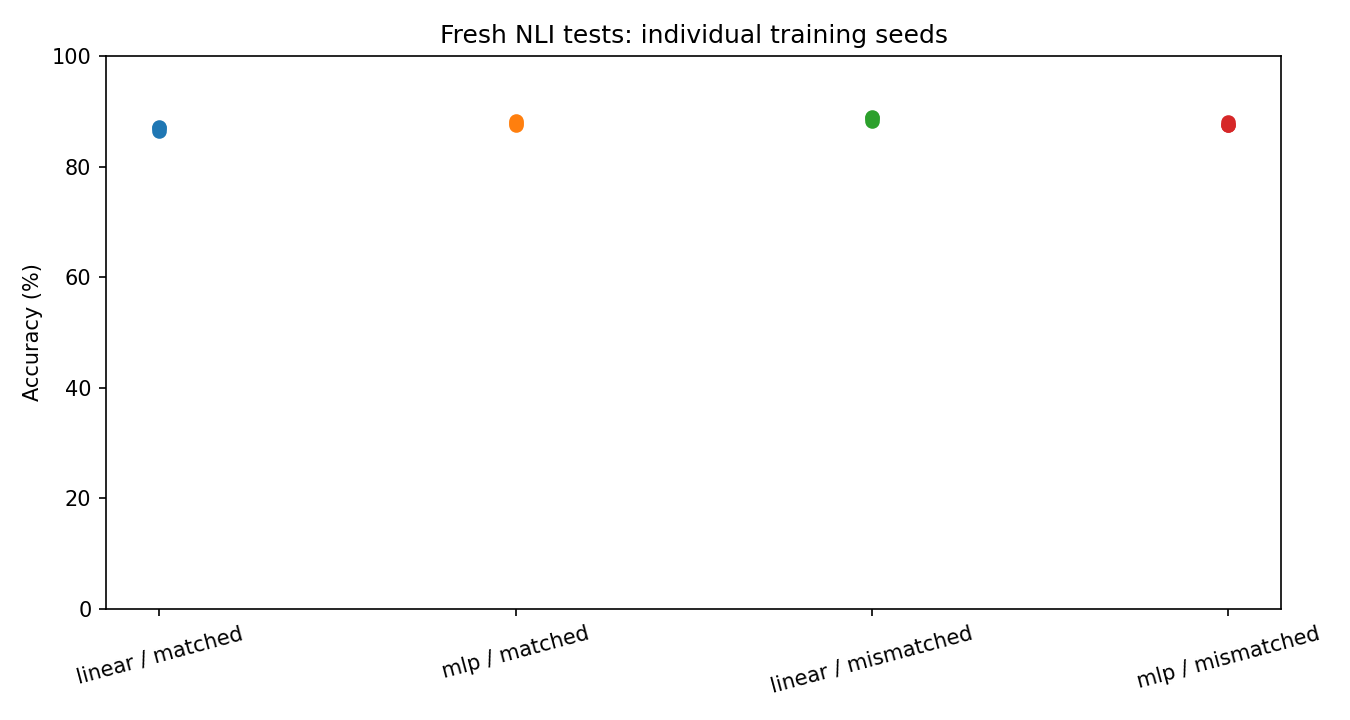

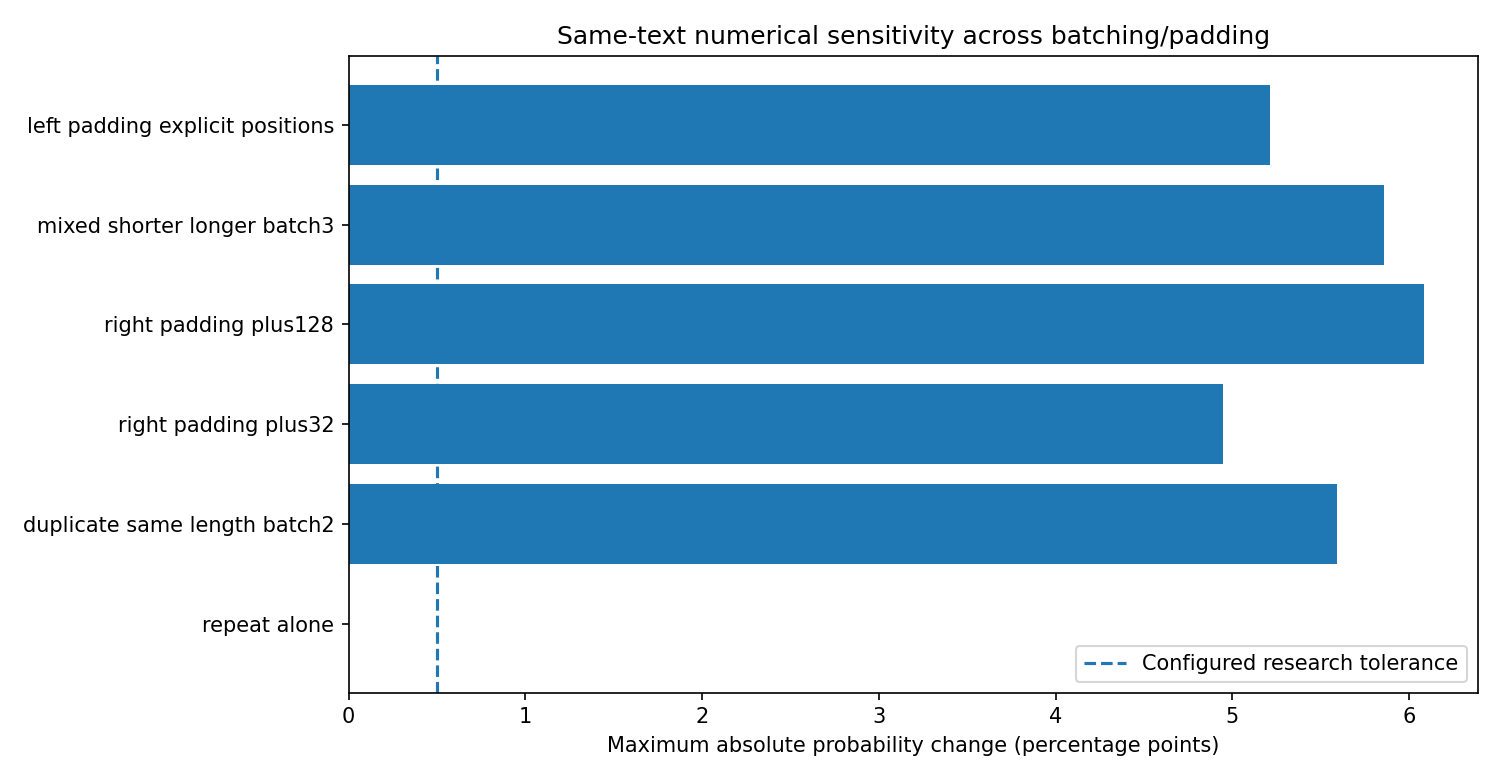

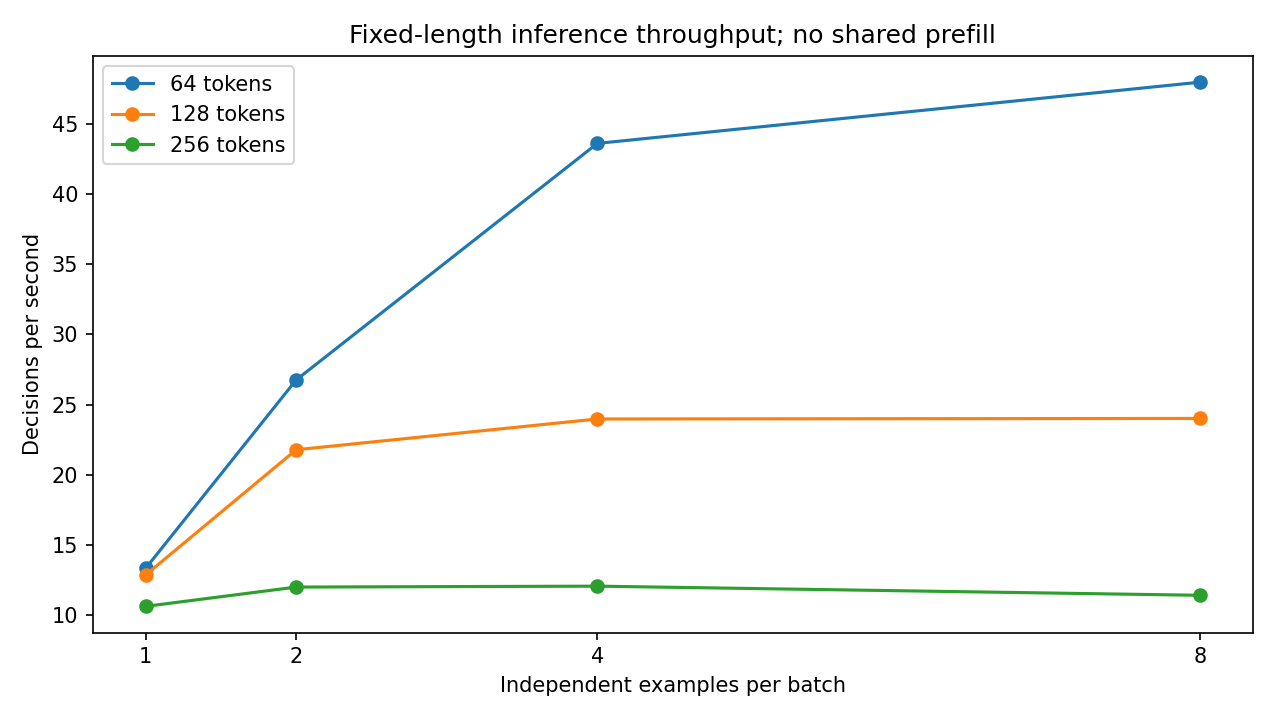

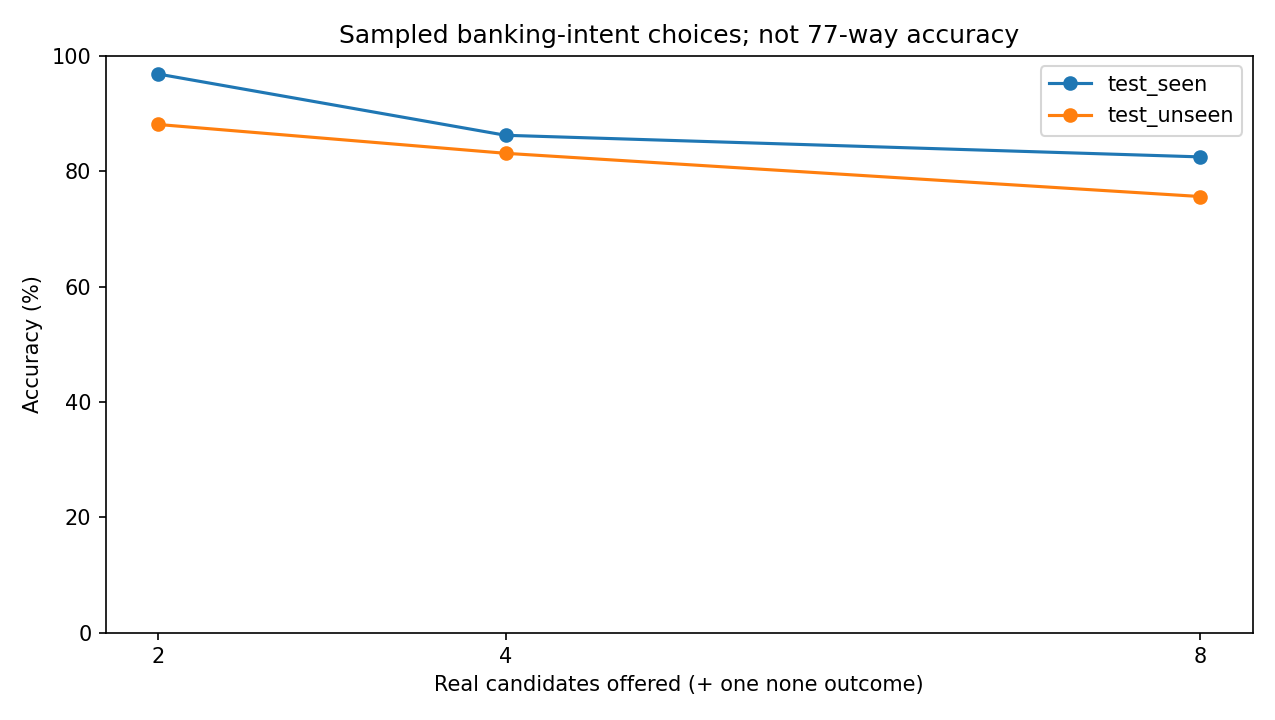

===== BEGIN_OPENKIND_PHASE2C_SUMMARY =====
{
  "schema": "openkind-phase2c-summary/v1",
  "run_id": "20260917T222948Z",
  "version": "2c.1.0",
  "stage_status": {
    "setup": "completed",
    "data": "completed",
    "model": "completed",
    "reference_head": "completed",
    "stability": "completed",
    "feature_extraction": "completed",
    "multi_seed_training": "completed",
    "calibration_selection": "completed",
    "fresh_nli_evaluation": "completed",
    "performance": "completed",
    "frozen_export": "completed",
    "dynamic": "completed",
    "dynamic_robustness": "completed",
    "lora": "disabled",
    "report": "completed"
  },
  "model": {
    "id": "Qwen/Qwen3.5-4B-Base",
    "revision": "1001bb4d826a52d1f399e183466143f4da7b741b",
    "text_class": "Qwen3_5TextModel",
    "hidden_size": 2560,
    "parameters": 4205751296,
    "input_output_weights_tied": true,
    "layer_types": [
      "linear_attention",
      "linear_attention",
      "linear_attention",
      "

In [24]:
PLOTS=save_plots(REPORT,OUT/'plots')
for path in PLOTS:display(Image(filename=path))
checkpoint('report')
SUMMARY=compact_summary(REPORT)
json_write(OUT/'openkind_phase2c_summary.json',REPORT)
json_write(OUT/'paste_back_summary.json',SUMMARY)
lines=['# OpenKind Phase 2C — measured readout','',f'Run: {RUN_ID}',
       f"GPU: {REPORT['environment']['gpu']}; dtype: {REPORT['environment']['dtype']}",
       f"Stability status: {REPORT['stability']['status']}",f'NLI development-selected head: {PRIMARY}',
       f"Dynamic stage: {REPORT.get('dynamic',{}).get('status')}",f"LoRA stage: {REPORT['lora']['status']}",
       '', '## Selected NLI results']
for r in SUMMARY['nli_selected_results']:
    lines.append(f"- {r['split']}: accuracy {r['accuracy']:.4f}; NLL {r['nll']:.4f}; ECE {r['ece_toplabel_15bins']:.4f}; temperature {r['temperature']:.4f}")
lines.extend(['','## Limitations']+['- '+s for s in REPORT['limitations']])
(OUT/'openkind_phase2c_summary.md').write_text(chr(10).join(lines),encoding='utf-8')
print('===== BEGIN_OPENKIND_PHASE2C_SUMMARY =====')
print(json.dumps(json_ready(SUMMARY),indent=2,allow_nan=False))
print('===== END_OPENKIND_PHASE2C_SUMMARY =====')

## 18 · Save reports and archive to Drive
The archive excludes activation caches, the old reference archive, HF credentials and backbone weights. It includes
new predictions, manifests, plots, heads and optional adapters. It is saved under a **new run folder**, not over Phase 2B.
Send back `paste_back_summary.json`; the full archive supports deeper checks and a future Rust implementation.

In [25]:
ARCHIVE=archive_results(OUT)
print('Local results:',OUT)
print('Result archive:',ARCHIVE)
if CFG.save_to_drive:
    try:
        from google.colab import drive
        drive.mount('/content/drive',force_remount=False)
        destination=Path('/content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2C_results')/RUN_ID
        destination.mkdir(parents=True,exist_ok=True)
        for name in ('paste_back_summary.json','openkind_phase2c_summary.json','openkind_phase2c_summary.md','nli_metrics.csv'):
            shutil.copy2(OUT/name,destination/name)
        shutil.copy2(ARCHIVE,destination/ARCHIVE.name)
        print('Copied reports/archive to:',destination)
    except Exception as error:
        print('Drive copy failed; local results remain available:',sanitize_error(error))
for path in (OUT/'paste_back_summary.json',OUT/'openkind_phase2c_summary.json',ARCHIVE):
    display(FileLink(str(path)))
print('Send paste_back_summary.json or the printed BEGIN/END summary. No HF_TOKEN is included.')

Local results: /content/openkind_phase2c/20260917T222948Z
Result archive: /content/openkind_phase2c/openkind_phase2c_20260917T222948Z.zip
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied reports/archive to: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase2C_results/20260917T222948Z


/content/openkind_phase2c/20260917T222948Z/paste_back_summary.json

/content/openkind_phase2c/20260917T222948Z/openkind_phase2c_summary.json

/content/openkind_phase2c/openkind_phase2c_20260917T222948Z.zip

Send paste_back_summary.json or the printed BEGIN/END summary. No HF_TOKEN is included.


## Interpretation and sources
A high fresh NLI score supports a fixed semantic probe—not arbitrary decision generalization. A good held-out-intent
score supports transfer within this sampled banking setup—not a frontier-model substitute. Stable batching under these
checks is a measured property of the recorded environment, not every hardware/kernel combination.

The next engineering choice should follow the full report: resolve numerical sensitivity first, then compare the
frozen and optional adapter paths on the actual target domain. Preserve these tests after the first readout; do not
iterate hyperparameters against the already inspected test results.

Primary implementation references (checked September 17, 2026):
- [Qwen3.5 text model and hybrid architecture](https://huggingface.co/docs/transformers/model_doc/qwen3_5)
- [PyTorch numerical accuracy and batched-vs-sliced computation](https://docs.pytorch.org/docs/main/notes/numerical_accuracy.html)
- [PyTorch native BF16 detection](https://docs.pytorch.org/docs/stable/generated/torch.cuda.is_bf16_supported.html)
- [PEFT LoRA API](https://huggingface.co/docs/peft/package_reference/lora)
- [MultiNLI dataset](https://huggingface.co/datasets/nyu-mll/multi_nli)
- [Banking77 dataset](https://huggingface.co/datasets/PolyAI/banking77)

**Authoring validation:** source/format checks and CPU tests use mock models and the real saved Phase 2B head fixtures.
The full 4B model, CUDA stability results, public-dataset GPU experiment and optional LoRA have **not** been executed
by the notebook author. Only a completed Colab run supplies those measurements. The result summary labels skipped and
failed stages explicitly.